In [62]:
import numpy as np
import pandas as pd
import os 
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import sem
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

# Set up plotting style
plt.rcParams.update({'font.size': 12})
sns.set_style("whitegrid")


In [63]:
# Configuration for paw speed
base_path = "/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results"


eids = [
    "15b69921-d471-4ded-8814-2adad954bcd8",    
    "15763234-d21e-491f-a01b-1238eb96d389", 
    "aad23144-0e52-4eac-80c5-c4ee2decb198",
    "9b528ad0-4599-4a55-9148-96cc1d93fb24",
    "4b00df29-3769-43be-bb40-128b1cba6d35",
    "0841d188-8ef2-4f20-9828-76a94d5343a4", # resnet is doing better than MVT
    "f312aaec-3b6f-44b3-86b4-3a0c119c0438",
    "0f77ca5d-73c2-45bd-aa4c-4c5ed275dbde",
    "1b715600-0cbc-442c-bd00-5b0ac2865de1",
    
    "3bcb81b4-d9ca-4fc9-a1cd-353a966239ca",
    # "03d9a098-07bf-4765-88b7-85f8d8f620cc", # very bad with EKS 
    "3e6a97d3-3991-49e2-b346-6948cb4580fb",
    "3f859b5c-e73a-4044-b49e-34bb81e96715", # bad with EKS 
    "4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b",
    "5ae68c54-2897-4d3a-8120-426150704385",
    "5dcee0eb-b34d-4652-acc3-d10afc6eae68",
    # "6c6b0d06-6039-4525-a74b-58cfaa1d3a60", # I used to comment out - in general can remove but will decide later
    "7cb81727-2097-4b52-b480-c89867b5b34c",
    "8a3a0197-b40a-449f-be55-c00b23253bbf",
    "30c4e2ab-dffc-499d-aae4-e51d6b3218c2",
    "51e53aff-1d5d-4182-a684-aba783d50ae5",
    # "61e11a11-ab65-48fb-ae08-3cb80662e5d6", # bad with EKS 
    "746d1902-fa59-4cab-b0aa-013be36060d5",
    "824cf03d-4012-4ab1-b499-c83a92c5589e",

    "3638d102-e8b6-4230-8742-e548cd87a949",
    "6899a67d-2e53-4215-a52a-c7021b5da5d4",
    "8928f98a-b411-497e-aa4b-aa752434686d",

    # This 2 sessions need to be removed
    # "71e55bfe-5a3a-4cba-bdc7-f085140d798e",
    # "754b74d5-7a06-4004-ae0c-72a10b6ed2e6",
    # "5c0c560e-9e1f-45e9-b66e-e4ee7855be84",
]

# eid = "0841d188-8ef2-4f20-9828-76a94d5343a4"
eid = "15763234-d21e-491f-a01b-1238eb96d389" # this is a good session
# eid = "7cb81727-2097-4b52-b480-c89867b5b34c"

# target = "lightning-pose-left-pawL-speed"  # The paw speed target we decoded
# target = "lightning-pose-right-pawL-speed"  # The paw speed target we decoded
# target = "lightning-pose-left-pawR-speed"  # The paw speed target we decoded
# target = "lightning-pose-right-pawR-speed"  # The paw speed target we decoded
target = "lightning-pose-pawL-3d-speed"  # The paw speed target we decoded
# target = "lightning-pose-pawR-3d-speed" 

model = "linear"
# model = "reduced_rank"

# Define the two pose models to compare
# pose_models = ["resnet50_median", "MVT_3d_aug_patch_median", "MVT_3d_aug_patch_eks_linear"]
# pose_models = ["resnet50_median", "MVT_3d_aug_patch_median", "MVT_3d_aug_patch_eks_linear", "resnet50_eks_linear"]
# pose_models = ["resnet50_median", "MVT_3d_aug_patch_median", "MVT_3d_aug_patch_median_400"]
# pose_models = ["resnet50_median_new", "MVT_3d_aug_patch_median_new", "MVT_3d_aug_patch_eks_linear_new"]
pose_models = ["resnet50_median_new", "MVT_3d_aug_patch_median_new", "MVT_3d_aug_patch_eks_linear_new"]
# pose_models = ["resnet50_median_new", "MVT_3d_loss_patch_median_new", "MVT_3d_aug_patch_eks_linear_new"]
# pose_models = ["resnet50_median_new", "MVT_3d_aug_patch_median_new", "MVT_3d_loss_patch_median_new"]
# pose_models = ["resnet50_median", "MVT_3d_aug_patch_median"]
# pose_models = ["resnet50_median"]




In [64]:
import os
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

def load_session_results(base_path, eid, target, pose_models, model_method="linear"):
    """
    Loads cross-validation results for multiple pose models.
    Automatically detects and flattens all coordinate and variance data,
    including 3D triangulation and multi-view keys.
    """
    results = {}
    
    for pose_model in pose_models:
        results_path = f"{base_path}/{eid}/{target}/{pose_model}/{model_method}/all/{eid}_cv.npy"
        
        if not os.path.exists(results_path):
            print(f"Warning: Results not found at {results_path}")
            continue
            
        print(f"\n{'='*40}")
        print(f"Loading: {pose_model}")
        
        # Load the data dictionary
        data = np.load(results_path, allow_pickle=True).item()
        
        # 1. Core Speed Data
        test_y = data['all_test_y']
        test_pred = data['all_test_pred']
        y_flat = test_y.flatten()
        pred_flat = test_pred.flatten()
                
        # 2. Initialize result container for this model
        res = {
            'test_y': test_y,
            'test_pred': test_pred,
            'y_flattened': y_flat,
            'pred_flattened': pred_flat,
            'test_metric': data['overall_metric'],
            'r2': r2_score(y_flat, pred_flat),
            'mse': mean_squared_error(y_flat, pred_flat),
            'correlation': np.corrcoef(y_flat, pred_flat)[0, 1],
            # Mapping Info
            'test_frame_indices': data.get('all_test_frame_indices'),
            'test_original_trial_ids': data.get('all_test_original_trial_indices')
        }
        
        # 3. Dynamic Ensemble/Coordinate extraction
        # This will automatically pick up: x_ens_var, left_x_ens_var, x_3d, etc.
        ens_data = data.get('all_test_ens_vars', {})
        for key, val in ens_data.items():
            if val is not None:
                res[key] = val
                res[f"{key}_flattened"] = val.flatten()
        
        # Load all available ensemble/coordinate data
        ens_data = data.get('all_test_ens_vars', {})
        for key, val in ens_data.items():
            if val is not None:
                res[key] = val
                res[f"{key}_flattened"] = val.flatten()
        
        # --- CALCULATE UNIFIED AVERAGE VARIANCE ---
        # CASE A: 2D Target (has x_ens_var and y_ens_var)
        if 'x_ens_var' in res and 'y_ens_var' in res:
            avg_var = (res['x_ens_var'] + res['y_ens_var']) / 2
            res['avg_ens_var_flattened'] = avg_var.flatten()
            
        # CASE B: 3D Target (has left_x_ens_var, right_x_ens_var, etc.)
        elif 'left_x_ens_var' in res and 'right_x_ens_var' in res:
            # Average across all 4 components (Left X, Left Y, Right X, Right Y)
            all_vars = [res['left_x_ens_var'], res['left_y_ens_var'], 
                        res['right_x_ens_var'], res['right_y_ens_var']]
            avg_var = sum(all_vars) / 4
            res['avg_ens_var_flattened'] = avg_var.flatten()

        results[pose_model] = res
        
        # Print summary
        print(f"  Target: {target}")
        print(f"  Session: {eid}")
        print(f"  Trials: {len(res['test_original_trial_ids']) if res['test_original_trial_ids'] is not None else 'Unknown'}")
        print(f"  R² (flattened): {res['r2']:.3f}")
        
        # List what was extracted (for debugging)
        extracted_keys = [k for k in ens_data.keys() if ens_data[k] is not None]
        if extracted_keys:
            print(f"  Extracted vars: {', '.join(extracted_keys)}")

    return results

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Collect data into a list of records
records = []
for eid1 in eids:
    results = load_session_results(base_path, eid1, target, pose_models, model_method=model)
    for pose_model in pose_models:
        if pose_model in results:
            records.append({
                'Session': eid1,
                'Model': pose_model,
                'R2': results[pose_model]['r2']
            })

df_results = pd.DataFrame(records)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.216
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

In [66]:
r2_values_sessions = []
for eid1 in eids:
    results = load_session_results(base_path, eid1, target, pose_models,model_method=model)
    
    # Extract R² values for each pose model in this session
    for pose_model in pose_models:
        if pose_model in results:
            r2_values_sessions.append(results[pose_model]['r2'])

# Calculate average R² across all sessions for each pose model
r2_by_model = {}
for eid1 in eids:
    results = load_session_results(base_path, eid1, target, pose_models, model_method=model)
    
    # Extract R² values for each pose model in this session
    for pose_model in pose_models:
        if pose_model in results:
            if pose_model not in r2_by_model:
                r2_by_model[pose_model] = []
            r2_by_model[pose_model].append(results[pose_model]['r2'])

# Print average R² for each pose model
print(f"\nAverage R² across all sessions by pose model:")
print(f" the target is {target}")
for pose_model in pose_models:
    if pose_model in r2_by_model and r2_by_model[pose_model]:
        avg_r2 = np.mean(r2_by_model[pose_model])
        std_r2 = np.std(r2_by_model[pose_model])
        print(f"  {pose_model}: {avg_r2:.3f} ± {std_r2:.3f} (n={len(r2_by_model[pose_model])})")
    else:
        print(f"  {pose_model}: No data found")



Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.216
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

  Target: lightning-pose-pawL-3d-speed
  Session: 7cb81727-2097-4b52-b480-c89867b5b34c
  Trials: 200
  R² (flattened): 0.293
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 7cb81727-2097-4b52-b480-c89867b5b34c
  Trials: 200
  R² (flattened): 0.327
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 8a3a0197-b40a-449f-be55-c00b23253bbf
  Trials: 273
  R² (flattened): 0.198
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-p

In [67]:
# Print average R² for each pose model
print(f"\nAverage R² across all sessions by pose model:")
print(f" the target is {target}")
for pose_model in pose_models:
    if pose_model in r2_by_model and r2_by_model[pose_model]:
        avg_r2 = np.mean(r2_by_model[pose_model])
        std_r2 = np.std(r2_by_model[pose_model])
        print(f"  {pose_model}: {avg_r2:.3f} ± {std_r2:.3f} (n={len(r2_by_model[pose_model])})")
    else:
        print(f"  {pose_model}: No data found")




Average R² across all sessions by pose model:
 the target is lightning-pose-pawL-3d-speed
  resnet50_median_new: 0.160 ± 0.062 (n=24)
  MVT_3d_aug_patch_median_new: 0.178 ± 0.067 (n=24)
  MVT_3d_aug_patch_eks_linear_new: 0.227 ± 0.072 (n=24)


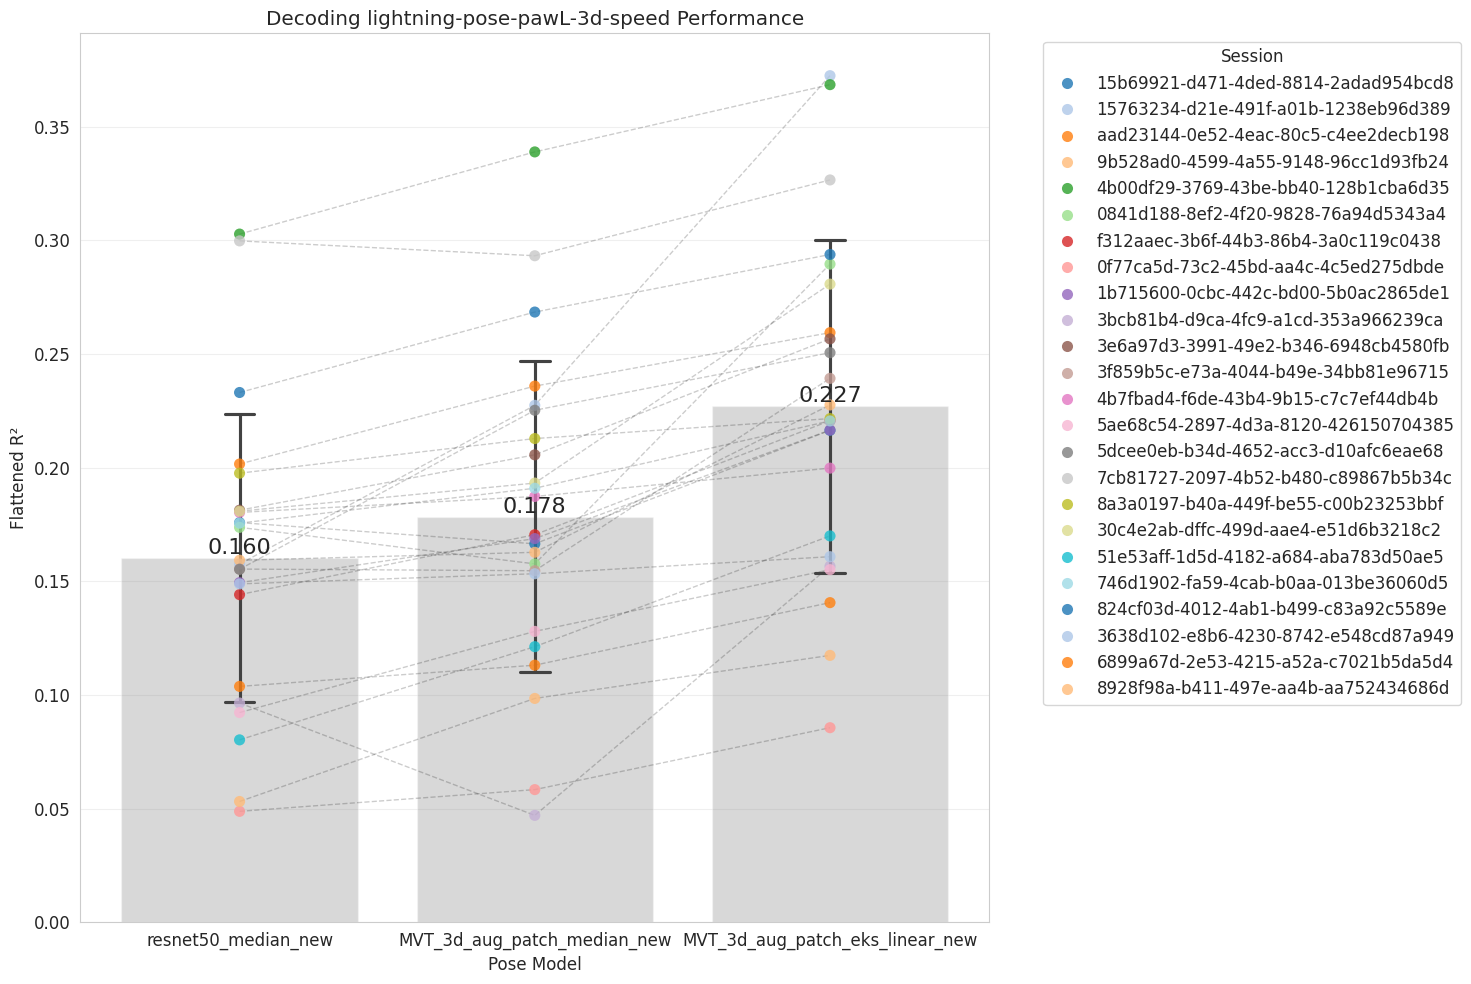

In [68]:
def plot_session_comparison(df, title="Model Performance Across Sessions"):
    plt.figure(figsize=(15, 10))
    
    # 1. Draw the Bars (Mean performance)
    # Change estimator=np.median if you prefer median over mean
    sns.barplot(data=df, x='Model', y='R2', alpha=0.3, color='gray', capsize=.1, errorbar='sd')
    
    # 2. Draw the Individual Session Points
    # palette='viridis' or any other color scheme you like
    sns.stripplot(data=df, x='Model', y='R2', hue='Session', size=8, jitter=False, palette='tab20', alpha=0.8)

    # add the averaged R^2 value for each model below its graph for up to 3 decimal values
    for model in df['Model'].unique():
        model_data = df[df['Model'] == model]
        avg_r2 = model_data['R2'].mean()
        plt.text(model, avg_r2, f'{avg_r2:.3f}', ha='center', va='bottom', fontsize=16)
    
    # 3. Draw Connecting Lines
    # We pivot to get a matrix where rows=sessions, cols=models
    pivot_df = df.pivot(index='Session', columns='Model', values='R2')
    # Get the x-positions of the bars for plotting lines correctly
    model_order = [m for m in df['Model'].unique() if m in pivot_df.columns]
    x_coords = range(len(model_order))
    
    for session_id, row in pivot_df.iterrows():
        # Plot a line for each session across the models
        y_values = [row[m] for m in model_order]
        plt.plot(x_coords, y_values, color='black', alpha=0.2, linestyle='--', linewidth=1, zorder=1)

    plt.title(title)
    plt.ylabel("Flattened R²")
    plt.xlabel("Pose Model")
    plt.ylim(bottom=0) # Often R2 is best viewed from 0 up
    plt.grid(axis='y', alpha=0.3)
    plt.legend(title="Session", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_session_comparison(df_results, title=f"Decoding {target} Performance")


ONE-SIDED STATISTICAL TEST (Baseline: resnet50_median_new)
  MVT_3d_aug_patch_median_new > resnet50_median_new: p-value = 1.0005e-03
  MVT_3d_aug_patch_eks_linear_new > resnet50_median_new: p-value = 5.9605e-08


/tmp/ipykernel_2539569/3147526002.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Model', y='R2', order=model_order,
/tmp/ipykernel_2539569/3147526002.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='Model', y='R2', order=model_order,


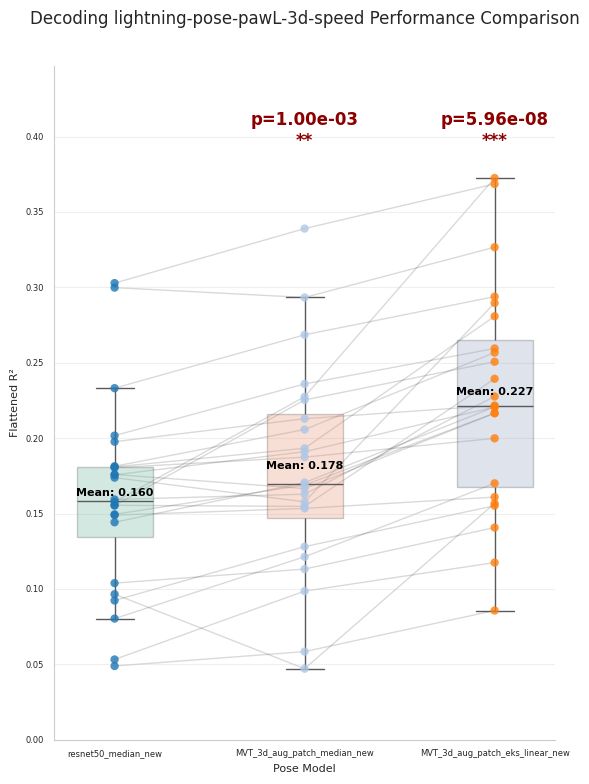

In [69]:
from scipy.stats import wilcoxon
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_session_comparison_with_stats(df, title="Model Performance Across Sessions"):
    """
    Plots IQR boxes with individual session dots and connecting lines.
    Performs one-sided Wilcoxon tests against the baseline (first model).
    """
    plt.figure(figsize=(6, 8))
    
    # 1. Setup Models and Pivot Data
    model_order = list(df['Model'].unique())
    baseline_model = model_order[0]
    pivot_df = df.pivot(index='Session', columns='Model', values='R2').dropna()
    
    # 2. Draw the IQR Boxes (Boxplot)
    # showfliers=False hides outliers so they don't double-plot with stripplot
    sns.boxplot(data=df, x='Model', y='R2', order=model_order, 
                palette='Set2', showfliers=False, width=0.4, boxprops=dict(alpha=0.3))
    
    # 3. Draw the Individual Session Points
    sns.stripplot(data=df, x='Model', y='R2', order=model_order, 
                  size=6, jitter=False, palette='tab20', alpha=0.8)

    # 4. Draw Connecting Lines (Paired comparison)
    x_coords = range(len(model_order))
    for _, row in pivot_df.iterrows():
        y_values = [row[m] for m in model_order]
        plt.plot(x_coords, y_values, color='black', alpha=0.15, linestyle='-', linewidth=1, zorder=0)

    # 5. Statistical Testing & Annotation
    print(f"\n{'='*60}")
    print(f"ONE-SIDED STATISTICAL TEST (Baseline: {baseline_model})")
    print(f"{'='*60}")
    
    y_max = df['R2'].max()
    
    for i, model in enumerate(model_order):
        # Calculate Mean for display
        avg_r2 = df[df['Model'] == model]['R2'].mean()
        plt.text(i, avg_r2, f'Mean: {avg_r2:.3f}', ha='center', va='bottom', 
                 fontsize=8, fontweight='bold', color='black')
        
        # Perform Stats against Baseline (skip the baseline itself)
        if model != baseline_model:
            # alternative='greater' tests if the current model > baseline
            _, p_val = wilcoxon(pivot_df[model], pivot_df[baseline_model], alternative='greater')
            
            print(f"  {model} > {baseline_model}: p-value = {p_val:.4e}")
            
            # Add p-value text to the plot
            stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
            plt.text(i, y_max * 1.05, f"p={p_val:.2e}\n{stars}", 
                     ha='center', va='bottom', color='darkred', fontweight='bold')
    

    plt.title(title, fontsize=12, pad=30)
    plt.ylabel("Flattened R²", fontsize=8)
    plt.xlabel("Pose Model", fontsize=8)
    plt.ylim(0, y_max * 1.2) # Make room for the p-values at the top
    plt.grid(axis='y', alpha=0.3)
    
    # Set x-axis tick label font size
    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)
    
    # Remove legend since we're not showing session names
    sns.despine()
    plt.tight_layout()
    plt.show()

# Run the updated function
plot_session_comparison_with_stats(df_results, title=f"Decoding {target} Performance Comparison")

In [70]:
# Define colors for each pose model
# Darker color for pose model (ground truth), lighter for decoded prediction
colors = {
    # 'MVT_patch_masking_median': {
    #     'pose': '#1f77b4',      # Dark blue
    #     'decoded': '#aec7e8'    # Light blue
    # },
    'MVT_3d_aug_patch_median': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_median': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    },

    'MVT_3d_aug_patch_median_new': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_median_new': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    },

    'MVT_3d_aug_patch_eks_linear_new': {
        'pose': 'green',      
        'decoded': 'lightgreen'    
    },

    # 'MVT_3d_aug_patch_eks': {
    #     'pose': 'green',      
    #     'decoded': 'lightgreen'    
    # },
    'MVT_3d_aug_patch_median_400': {
        'pose': 'purple',      # Dark blue
        'decoded': 'lightpurple'    # Light blue
    },

    'MVT_3d_aug_patch_eks_linear': {
        'pose': 'green',      
        'decoded': 'lightgreen'    
    },

    'MVT_3d_aug_patch_0': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_0': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    }
}


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.216
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

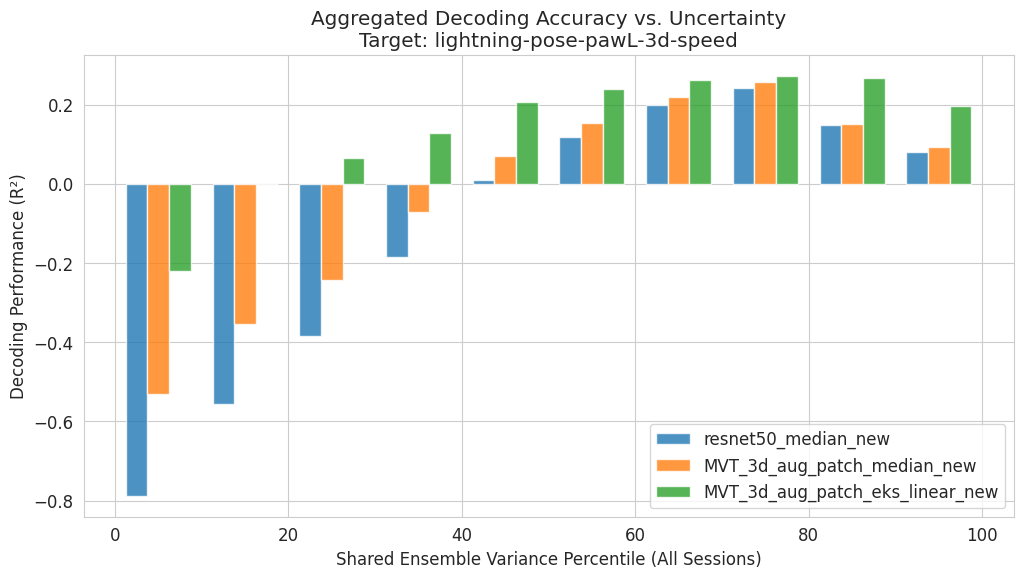

In [71]:
def plot_performance_by_shared_variance_all_sessions(base_path, eids, target, pose_models, n_bins=10):
    """
    Aggregates all sessions and plots R2 vs shared variance percentiles.
    """
    agg_data = {m: {'y': [], 'pred': [], 'var': []} for m in pose_models}

    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        for m in pose_models:
            if m in res_dict and 'avg_ens_var_flattened' in res_dict[m]:
                agg_data[m]['y'].append(res_dict[m]['y_flattened'])
                agg_data[m]['pred'].append(res_dict[m]['pred_flattened'])
                agg_data[m]['var'].append(res_dict[m]['avg_ens_var_flattened'])

    # Concatenate
    shared_vars = []
    for m in pose_models:
        agg_data[m]['y'] = np.concatenate(agg_data[m]['y'])
        agg_data[m]['pred'] = np.concatenate(agg_data[m]['pred'])
        agg_data[m]['var'] = np.concatenate(agg_data[m]['var'])
        shared_vars.append(agg_data[m]['var'])

    shared_var_scale = np.mean(shared_vars, axis=0)
    percentiles = np.linspace(0, 100, n_bins + 1)
    thresholds = np.percentile(shared_var_scale, percentiles)
    bin_centers = (percentiles[:-1] + percentiles[1:]) / 2

    plt.figure(figsize=(12, 6))
    width = 10 / (len(pose_models) + 1)
    
    for i, m in enumerate(pose_models):
        bin_r2s = []
        for j in range(n_bins):
            mask = (shared_var_scale >= thresholds[j]) & (shared_var_scale < thresholds[j+1])
            bin_r2s.append(r2_score(agg_data[m]['y'][mask], agg_data[m]['pred'][mask]))
        
        offset = (i - len(pose_models)/2 + 0.5) * width
        plt.bar(bin_centers + offset, bin_r2s, width=width, label=m, alpha=0.8)

    plt.xlabel('Shared Ensemble Variance Percentile (All Sessions)')
    plt.ylabel('Decoding Performance (R²)')
    plt.title(f'Aggregated Decoding Accuracy vs. Uncertainty\nTarget: {target}')
    plt.legend()
    plt.show()

plot_performance_by_shared_variance_all_sessions(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.216
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

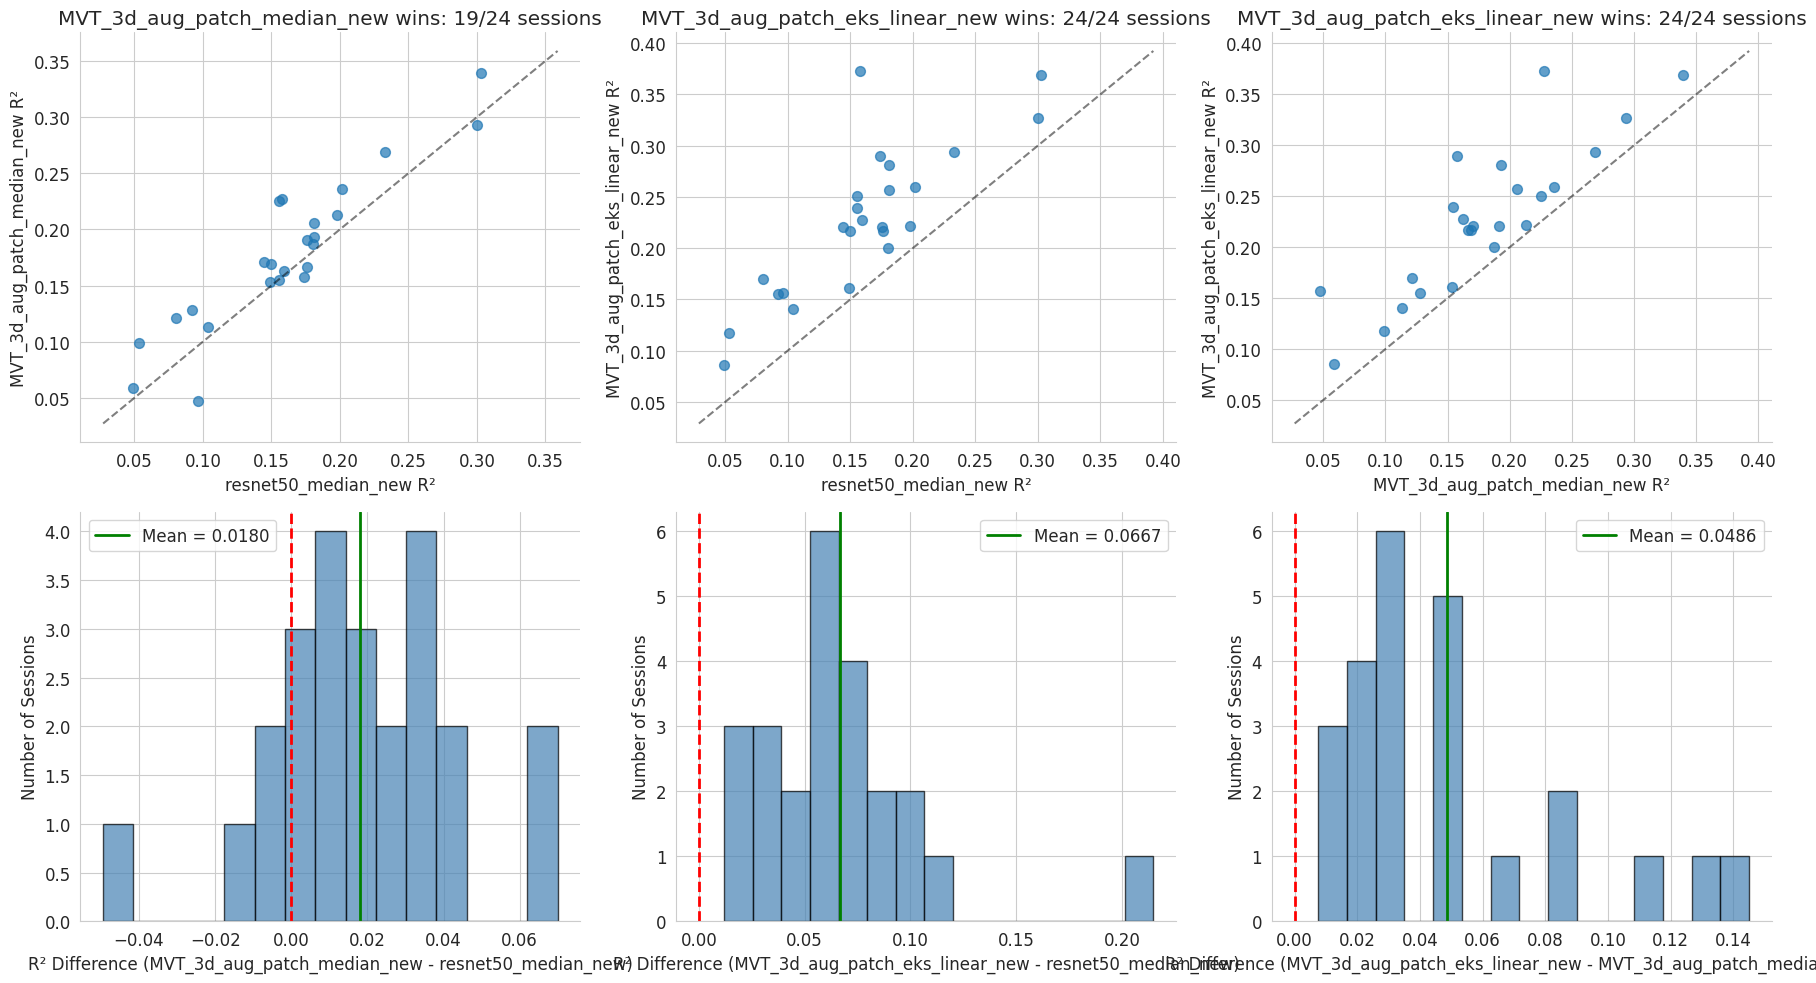

In [72]:
def plot_paired_session_comparison(base_path, eids, target, pose_models):
    """
    Paired comparison for multiple models showing which model wins per session.
    """
    session_results = []
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        
        row = {'eid': eid}
        for m in pose_models:
            if m in res_dict:
                y = res_dict[m]['y_flattened']
                pred = res_dict[m]['pred_flattened']
                row[m] = r2_score(y, pred)
        
        if len(row) == len(pose_models) + 1:  # All models present
            session_results.append(row)
    
    df = pd.DataFrame(session_results)
    
    n_models = len(pose_models)
    n_pairs = n_models * (n_models - 1) // 2  # Number of pairwise comparisons
    
    fig, axes = plt.subplots(2, n_pairs, figsize=(6*n_pairs, 10))
    if n_pairs == 1:
        axes = axes.reshape(2, 1)
    
    pair_idx = 0
    from scipy import stats
    
    print("=== Pairwise Comparisons ===\n")
    
    for i in range(n_models):
        for j in range(i+1, n_models):
            m1, m2 = pose_models[i], pose_models[j]
            
            # Top row: Scatter plot
            ax = axes[0, pair_idx]
            ax.scatter(df[m1], df[m2], alpha=0.7, s=50)
            lims = [min(df[m1].min(), df[m2].min()) - 0.02,
                    max(df[m1].max(), df[m2].max()) + 0.02]
            ax.plot(lims, lims, 'k--', alpha=0.5)
            ax.set_xlabel(f'{m1} R²')
            ax.set_ylabel(f'{m2} R²')
            
            # Count wins
            m2_wins = (df[m2] > df[m1]).sum()
            ax.set_title(f'{m2} wins: {m2_wins}/{len(df)} sessions')
            sns.despine(ax=ax)
            
            # Bottom row: Histogram of differences
            ax = axes[1, pair_idx]
            diff = df[m2] - df[m1]
            ax.hist(diff, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
            ax.axvline(0, color='red', linestyle='--', lw=2)
            ax.axvline(diff.mean(), color='green', linestyle='-', lw=2, 
                       label=f'Mean = {diff.mean():.4f}')
            ax.set_xlabel(f'R² Difference ({m2} - {m1})')
            ax.set_ylabel('Number of Sessions')
            ax.legend()
            sns.despine(ax=ax)
            
            # Stats
            t_stat, p_val = stats.ttest_rel(df[m2], df[m1])
            print(f"{m2} vs {m1}:")
            print(f"  Mean diff = {diff.mean():.4f}, t = {t_stat:.3f}, p = {p_val:.4f}")
            print(f"  {m2} wins {m2_wins}/{len(df)} sessions\n")
            
            pair_idx += 1
    
    plt.tight_layout()
    plt.show()
    
    return df


df = plot_paired_session_comparison(base_path, eids, target, pose_models)

In [73]:
def diagnose_low_variance_bins(base_path, eids, target, pose_models, n_bins=10):
    """
    Diagnose why low variance bins have negative R².
    """
    agg_data = {m: {'y': [], 'pred': [], 'var': []} for m in pose_models}
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        for m in pose_models:
            if m in res_dict and 'avg_ens_var_flattened' in res_dict[m]:
                agg_data[m]['y'].append(res_dict[m]['y_flattened'])
                agg_data[m]['pred'].append(res_dict[m]['pred_flattened'])
                agg_data[m]['var'].append(res_dict[m]['avg_ens_var_flattened'])
    
    # Concatenate
    for m in pose_models:
        agg_data[m]['y'] = np.concatenate(agg_data[m]['y'])
        agg_data[m]['pred'] = np.concatenate(agg_data[m]['pred'])
        agg_data[m]['var'] = np.concatenate(agg_data[m]['var'])
    
    shared_vars = [agg_data[m]['var'] for m in pose_models]
    shared_var_scale = np.mean(shared_vars, axis=0)
    
    percentiles = np.linspace(0, 100, n_bins + 1)
    thresholds = np.percentile(shared_var_scale, percentiles)
    thresholds[-1] += 1e-9
    
    m = pose_models[0]  # Check first model
    
    print("=== Diagnosis by Variance Bin ===\n")
    print(f"{'Bin':<10} {'N':<8} {'Mean Y':<10} {'Std Y':<10} {'Mean Pred':<10} {'R²':<10}")
    print("-" * 60)
    
    for j in range(n_bins):
        mask = (shared_var_scale >= thresholds[j]) & (shared_var_scale < thresholds[j+1])
        
        y_bin = agg_data[m]['y'][mask]
        pred_bin = agg_data[m]['pred'][mask]
        
        if len(y_bin) < 2:
            continue
        
        r2 = r2_score(y_bin, pred_bin)
        
        print(f"{j*10}-{(j+1)*10}%    {len(y_bin):<8} {np.mean(y_bin):<10.4f} {np.std(y_bin):<10.4f} {np.mean(pred_bin):<10.4f} {r2:<10.4f}")


diagnose_low_variance_bins(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.216
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: aad23144-0e52-4eac-80c5-c4ee2decb198
  Trials: 372
  R² (flattened): 0.202
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightn

  Target: lightning-pose-pawL-3d-speed
  Session: 3bcb81b4-d9ca-4fc9-a1cd-353a966239ca
  Trials: 222
  R² (flattened): 0.097
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 3e6a97d3-3991-49e2-b346-6948cb4580fb
  Trials: 374
  R² (flattened): 0.181
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 3f859b5c-e73a-4044-b49e-34bb81e96715
  Trials: 300
  R² (flattened): 0.155
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Sessi

/tmp/ipykernel_2539569/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_2539569/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_2539569/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_2539569/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_2539569/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_2539569/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_2539569/170926472.py:26: RuntimeWarning: invalid value encountered in sqrt
  std_dev = np.sqrt(res['avg_ens_var_flattened'])
/tmp/ipykernel_25395

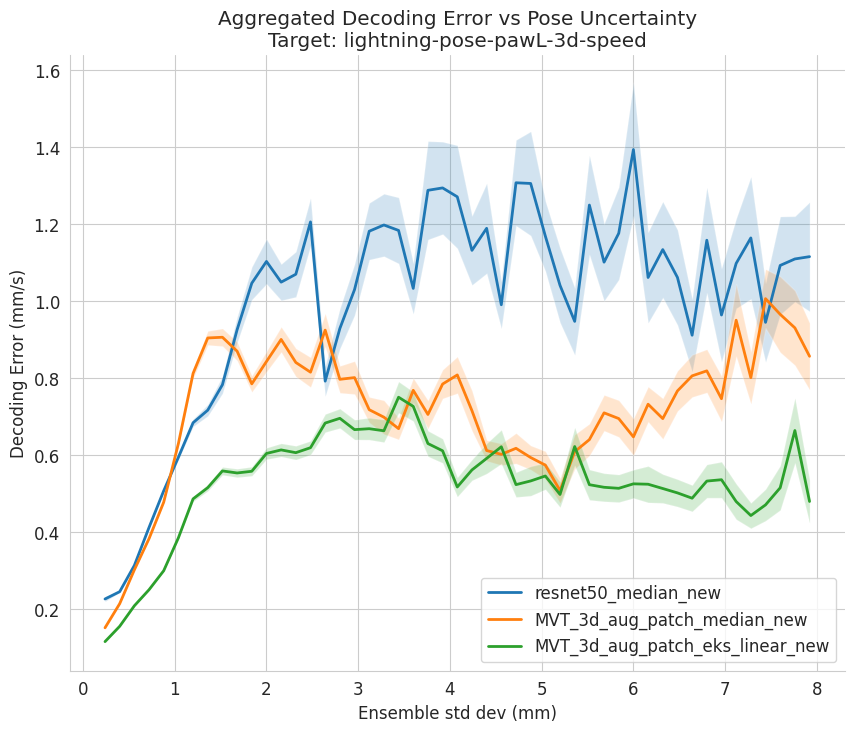

In [ ]:
# def plot_decoding_error_vs_std_all_sessions(base_path, eids, target, pose_models, n_bins=50, max_std=8):
#     """
#     Aggregates all sessions and plots absolute error vs ensemble std dev.
#     """
#     plt.figure(figsize=(10, 8))
    
#     # Determine units for the label
#     # If 3D, it's usually mm/s or m/s. If 2D, it's pixels/s.
#     unit_label = "mm/s" if "3d" in target.lower() else "pix/s"
    
#     bins = np.linspace(0, max_std, n_bins + 1)
#     bin_centers = (bins[:-1] + bins[1:]) / 2

#     for m_name in pose_models:
#         all_errors, all_stds = [], []
#         for eid in eids:
#             res_dict = load_session_results(base_path, eid, target, [m_name])
#             if m_name in res_dict and 'avg_ens_var_flattened' in res_dict[m_name]:
#                 res = res_dict[m_name]
                
#                 # y_true and y_pred are already in the target units (e.g., mm/s)
#                 # because we disabled min-max normalization for lightning-pose
#                 error = np.abs(res['y_flattened'] - res['pred_flattened'])
                
#                 # Ensemble std is also in the same physical units (mm or pixels)
#                 std_dev = np.sqrt(res['avg_ens_var_flattened'])
                
#                 all_errors.append(error)
#                 all_stds.append(std_dev)
        
#         if not all_errors: continue
        
#         errors = np.concatenate(all_errors)
#         stds = np.concatenate(all_stds)
        
#         means, sems = [], []
#         for i in range(n_bins):
#             mask = (stds >= bins[i]) & (stds < bins[i+1])
#             if np.sum(mask) > 50:
#                 means.append(np.mean(errors[mask]))
#                 sems.append(sem(errors[mask]))
#             else:
#                 means.append(np.nan); sems.append(np.nan)
        
#         plt.plot(bin_centers, means, label=m_name, linewidth=2)
#         plt.fill_between(bin_centers, np.array(means)-np.array(sems), np.array(means)+np.array(sems), alpha=0.2)

#     plt.xlabel(f'Ensemble std dev ({unit_label.split("/")[0]})') # e.g., "mm" or "pix"
#     plt.ylabel(f'Decoding Error ({unit_label})')               # e.g., "mm/s" or "pix/s"
#     plt.title(f'Aggregated Decoding Error vs Pose Uncertainty\nTarget: {target}')
#     plt.legend()
#     sns.despine()
#     plt.show()

# plot_decoding_error_vs_std_all_sessions(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.216
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

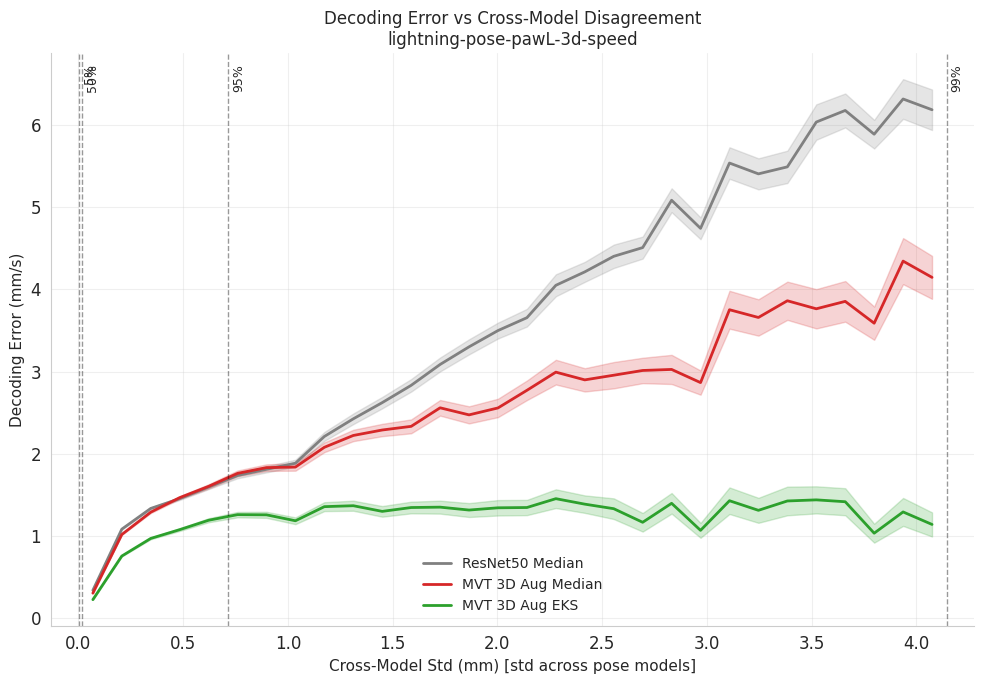

In [ ]:
# def plot_with_cross_model_std(base_path, eids, target, pose_models,
#                                n_bins=30, min_points=30,
#                                percentiles=[5,50, 95, 99]):
#     """
#     Compute ensemble std ACROSS different pose models (like Lightning Pose reference).
#     X-axis = std(resnet_prediction, mvt_prediction, eks_prediction) per frame.
#     """
#     unit_label = "mm/s" if "3d" in target.lower() else "pix/s"
#     std_unit = unit_label.split("/")[0]
    
#     # Step 1: Collect predictions (ground truth speed) from each model
#     all_data = {m: {'error': [], 'ground_truth': []} for m in pose_models}
#     cross_model_std_all = []
    
#     for eid in eids:
#         res_dict = load_session_results(base_path, eid, target, pose_models)
        
#         # Only use sessions where ALL models have data
#         if not all(m in res_dict for m in pose_models):
#             continue
        
#         # Get ground truth (y) from each model - these are the POSE ESTIMATES
#         # The "y_flattened" is the speed computed from pose coordinates
#         model_preds = []
#         for m in pose_models:
#             model_preds.append(res_dict[m]['y_flattened'])
        
#         # Stack: shape (n_models, n_frames)
#         model_preds = np.stack(model_preds, axis=0)
        
#         # Compute CROSS-MODEL std (like Lightning Pose reference)
#         cross_model_std = np.std(model_preds, axis=0)  # std across models
#         cross_model_std_all.append(cross_model_std)
        
#         # Collect errors for each model
#         for m in pose_models:
#             res = res_dict[m]
#             error = np.abs(res['y_flattened'] - res['pred_flattened'])
#             all_data[m]['error'].append(error)
#             all_data[m]['ground_truth'].append(res['y_flattened'])
    
#     # Concatenate
#     cross_model_std_combined = np.concatenate(cross_model_std_all)
#     for m in pose_models:
#         all_data[m]['error'] = np.concatenate(all_data[m]['error'])
    
#     print(f"Total frames: {len(cross_model_std_combined)}")
#     print(f"Cross-model std range: {cross_model_std_combined.min():.3f} - {cross_model_std_combined.max():.3f}")
    
#     # Auto max_std
#     max_std = np.percentile(cross_model_std_combined, 99)
#     bins = np.linspace(0, max_std, n_bins + 1)
#     bin_centers = (bins[:-1] + bins[1:]) / 2
    
#     # Colors and labels
#     colors = {
#         'resnet50_median_new': 'gray',
#         'MVT_3d_aug_patch_median_new': '#d62728',
#         'MVT_3d_aug_patch_eks_linear_new': '#2ca02c',
#     }
#     labels = {
#         'resnet50_median_new': 'ResNet50 Median',
#         'MVT_3d_aug_patch_median_new': 'MVT 3D Aug Median',
#         'MVT_3d_aug_patch_eks_linear_new': 'MVT 3D Aug EKS',
#     }
    
#     fig, ax = plt.subplots(figsize=(10, 7))
    
#     # Plot
#     for m in pose_models:
#         errors = all_data[m]['error']
#         means, sems = [], []
        
#         for i in range(n_bins):
#             mask = (cross_model_std_combined >= bins[i]) & (cross_model_std_combined < bins[i+1])
#             n_pts = np.sum(mask)
#             if n_pts >= min_points:
#                 means.append(np.mean(errors[mask]))
#                 sems.append(sem(errors[mask]))
#             else:
#                 means.append(np.nan)
#                 sems.append(np.nan)
        
#         means, sems = np.array(means), np.array(sems)
#         ax.plot(bin_centers, means, label=labels.get(m, m), color=colors.get(m, 'gray'), linewidth=2)
#         ax.fill_between(bin_centers, means - sems, means + sems, color=colors.get(m, 'gray'), alpha=0.2)
    
#     # Percentile lines
#     for p in percentiles:
#         val = np.percentile(cross_model_std_combined, p)
#         ax.axvline(val, linestyle='--', color='black', alpha=0.4, linewidth=1)
#         ax.text(val + 0.02, ax.get_ylim()[1] * 0.98, f'{p}%', fontsize=9, rotation=90, va='top')
    
#     ax.set_xlabel(f'Cross-Model Std ({std_unit}) [std across pose models]', fontsize=11)
#     ax.set_ylabel(f'Decoding Error ({unit_label})', fontsize=11)
#     ax.set_title(f'Decoding Error vs Cross-Model Disagreement\n{target}', fontsize=12)
#     ax.legend(fontsize=10, frameon=False)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     return fig


# # RUN: Cross-model std (exactly like Lightning Pose reference)
# fig = plot_with_cross_model_std(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.216
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

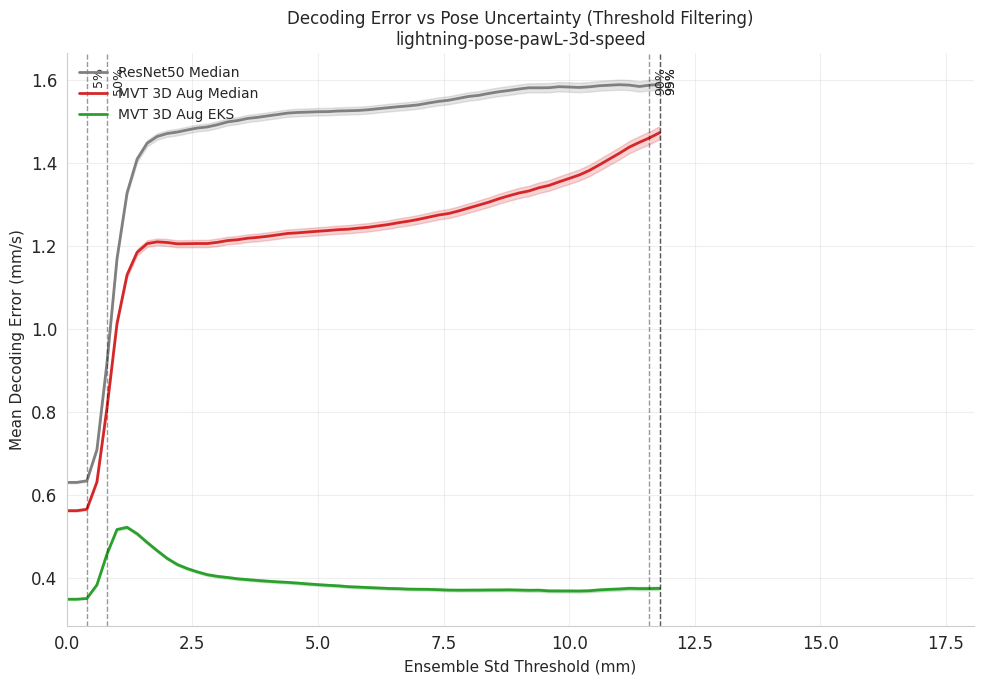

In [97]:
def plot_with_threshold_filtering(base_path, eids, target, pose_models,
                                   std_vals=np.arange(0, 12, 0.2),
                                   min_points=50,
                                   percentiles=[50, 75, 90, 95, 99]):
    """
    Lightning Pose approach: For each threshold, compute mean error of ALL points
    where ensemble std > threshold. NO BINNING.
    """
    unit_label = "mm/s" if "3d" in target.lower() else "pix/s"
    std_unit = unit_label.split("/")[0]
    
    # Step 1: Collect data
    all_data = {m: {'error': [], 'ens_std': []} for m in pose_models}
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        if not all(m in res_dict and 'avg_ens_var_flattened' in res_dict[m] for m in pose_models):
            continue
        
        for m in pose_models:
            res = res_dict[m]
            error = np.abs(res['y_flattened'] - res['pred_flattened'])
            var = res['avg_ens_var_flattened']
            ens_std = np.sqrt(np.maximum(var, 0))
            all_data[m]['error'].append(error)
            all_data[m]['ens_std'].append(ens_std)
    
    # Concatenate
    for m in pose_models:
        all_data[m]['error'] = np.concatenate(all_data[m]['error'])
        all_data[m]['ens_std'] = np.concatenate(all_data[m]['ens_std'])
    
    # Compute avg internal ensemble std
    ens_std_stack = np.stack([all_data[m]['ens_std'] for m in pose_models], axis=0)
    avg_ens_std = np.mean(ens_std_stack, axis=0)
    
    print(f"Total frames: {len(avg_ens_std)}")
    
    # Colors and labels
    colors = {
        'resnet50_median_new': 'gray',
        'MVT_3d_aug_patch_median_new': '#d62728',
        'MVT_3d_aug_patch_eks_linear_new': '#2ca02c',
    }
    labels = {
        'resnet50_median_new': 'ResNet50 Median',
        'MVT_3d_aug_patch_median_new': 'MVT 3D Aug Median',
        'MVT_3d_aug_patch_eks_linear_new': 'MVT 3D Aug EKS',
    }
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Track n_points for percentiles
    n_points_all = np.zeros(len(std_vals))
    
    # Step 2: For each model, compute mean error at each THRESHOLD (not bin!)
    for m in pose_models:
        errors = all_data[m]['error']
        means, sems, n_points = [], [], []
        
        for threshold in std_vals:
            # KEY DIFFERENCE: Filter ALL points where std > threshold
            mask = avg_ens_std > threshold
            n = np.sum(mask)
            n_points.append(n)
            
            if n >= min_points:
                means.append(np.mean(errors[mask]))
                sems.append(sem(errors[mask]))
            else:
                means.append(np.nan)
                sems.append(np.nan)
        
        means, sems = np.array(means), np.array(sems)
        n_points_all = np.array(n_points)  # Same for all models
        
        ax.plot(std_vals, means, label=labels.get(m, m), color=colors.get(m, 'gray'), linewidth=2)
        ax.fill_between(std_vals, means - sems, means + sems, color=colors.get(m, 'gray'), alpha=0.2)
    
    # Step 3: Add percentile lines (computed from n_points)
    total_points = n_points_all[0]  # At threshold=0, all points included
    print(f"\nPercentile lines (based on data distribution):")
    for p in percentiles:
        # Find threshold where (100-p)% of data remains
        target_n = total_points * (100 - p) / 100
        idx = np.argmin(np.abs(n_points_all - target_n))
        val = std_vals[idx]
        
        ax.axvline(val, linestyle='--', color='black', alpha=0.4, linewidth=1)
        ax.text(val + 0.1, ax.get_ylim()[1] * 0.98, f'{p}%', fontsize=9, rotation=90, va='top')
        print(f"  {p}%: std = {val:.2f} (keeping {100-p}% of data)")
    
    # Limit X-axis to 99th percentile
    max_x = np.percentile(avg_ens_std, 95)
    ax.set_xlim(0, max_x)
    
    # Style
    ax.set_xlabel(f'Ensemble Std Threshold ({std_unit})', fontsize=11)
    ax.set_ylabel(f'Mean Decoding Error ({unit_label})', fontsize=11)
    ax.set_title(f'Decoding Error vs Pose Uncertainty (Threshold Filtering)\n{target}', fontsize=12)
    ax.legend(fontsize=10, frameon=False, loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig


# RUN - Lightning Pose style (no binning)
fig = plot_with_threshold_filtering(
    base_path, eids, target, pose_models,
    std_vals=np.arange(0, 12, 0.2),
    percentiles=[5,50, 90, 95, 99]
)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.216
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

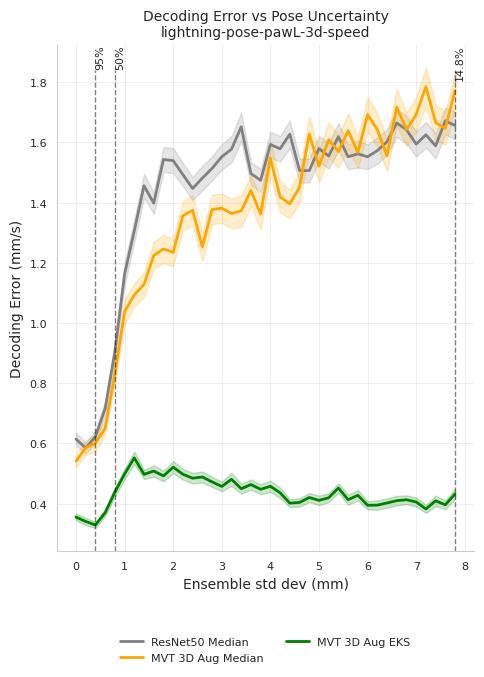

In [77]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import sem

def compute_percentiles(n_points_arr, std_vals, percentiles):
    """Find std values where X% of data is included."""
    num_pts = n_points_arr[0]
    vals, prctiles = [], []
    for p in percentiles:
        target = num_pts * p / 100
        idx = np.argmin(np.abs(n_points_arr - target))
        actual_p = n_points_arr[idx] / num_pts * 100 if idx == len(n_points_arr) - 1 else p
        vals.append(std_vals[idx])
        prctiles.append(np.round(actual_p, 2))
    return vals, prctiles


def prepare_decoding_line_data(base_path, eids, target, pose_models, 
                                std_vals=np.arange(0, 8, 0.2), 
                                max_samples_per_bin=5000):
    """
    Prepare line data following Lightning Pose approach.
    For each std threshold, stores errors of points where std > threshold.
    Uses subsampling for efficiency.
    """
    # Step 1: Aggregate all data across sessions
    agg_data = {m: {'error': [], 'std': []} for m in pose_models}
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        for m in pose_models:
            if m in res_dict and 'avg_ens_var_flattened' in res_dict[m]:
                res = res_dict[m]
                error = np.abs(res['y_flattened'] - res['pred_flattened'])
                var = res['avg_ens_var_flattened']
                std_dev = np.sqrt(np.maximum(var, 0))
                agg_data[m]['error'].append(error)
                agg_data[m]['std'].append(std_dev)
    
    # Concatenate
    for m in pose_models:
        if agg_data[m]['error']:
            agg_data[m]['error'] = np.concatenate(agg_data[m]['error'])
            agg_data[m]['std'] = np.concatenate(agg_data[m]['std'])
    
    # Step 2: Build line data (like Lightning Pose prepare_line_data)
    n_points_dict = {m: np.zeros(len(std_vals)) for m in pose_models}
    df_rows = []
    
    for s, std_threshold in enumerate(std_vals):
        for m in pose_models:
            if not len(agg_data[m]['error']):
                continue
            
            errors = agg_data[m]['error']
            stds = agg_data[m]['std']
            
            # Filter: keep points where std > threshold
            mask = stds > std_threshold
            n_points = np.sum(mask)
            n_points_dict[m][s] = n_points
            
            if n_points > 0:
                filtered_errors = errors[mask]
                
                # Subsample for efficiency (like Lightning Pose but with limit)
                if len(filtered_errors) > max_samples_per_bin:
                    idx = np.random.choice(len(filtered_errors), max_samples_per_bin, replace=False)
                    filtered_errors = filtered_errors[idx]
                
                # Store individual errors (Lightning Pose calls this column 'mean')
                for err in filtered_errors:
                    df_rows.append({
                        'ens-std': std_threshold,
                        'model': m,
                        'decoding_error': err,
                        'n_points': n_points
                    })
    
    df_line = pd.DataFrame(df_rows)
    return df_line, n_points_dict


def plot_decoding_comparison(base_path, eids, target, pose_models,
                              std_vals=np.arange(0, 8, 0.2),
                              percentiles=[95, 50, 5],
                              figsize=(5, 7),
                              color_mapping=None,
                              custom_labels=None):
    """
    Plot decoding error vs ensemble std following Lightning Pose approach.
    Shows mean error of points WHERE std > threshold (not binned).
    """
    # Prepare data
    df_line, n_points_dict = prepare_decoding_line_data(
        base_path, eids, target, pose_models, std_vals
    )
    
    if df_line.empty:
        print("No data to plot!")
        return None
    
    # Default colors
    if color_mapping is None:
        color_mapping = {
            'resnet50_median_new': 'gray',
            'MVT_3d_aug_patch_median_new': 'orange',
            'MVT_3d_aug_patch_eks_linear_new': 'green',
        }
    
    # Default labels
    if custom_labels is None:
        custom_labels = {
            'resnet50_median_new': 'ResNet50 Median',
            'MVT_3d_aug_patch_median_new': 'MVT 3D Aug Median',
            'MVT_3d_aug_patch_eks_linear_new': 'MVT 3D Aug EKS',
        }
    
    # Determine units
    unit_label = "mm/s" if "3d" in target.lower() else "pix/s"
    std_unit = unit_label.split("/")[0]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot each model (like Lightning Pose plot_comparison)
    for m in pose_models:
        model_data = df_line[df_line['model'] == m]
        if model_data.empty:
            continue
        
        # Print stats at threshold=0
        zero_data = model_data[model_data['ens-std'] == 0]
        if len(zero_data) > 0:
            print(f"{m}: Mean={zero_data['decoding_error'].mean():.3f}, "
                  f"SE={sem(zero_data['decoding_error']):.4f}, N={len(zero_data)}")
        
        # Use seaborn lineplot with SE (like Lightning Pose)
        sns.lineplot(
            x='ens-std',
            y='decoding_error',
            data=model_data,
            label=custom_labels.get(m, m),
            color=color_mapping.get(m, 'gray'),
            ax=ax,
            errorbar='se',
            linewidth=2
        )
    
    # Add percentile lines (like Lightning Pose)
    # Use first model's n_points for percentile calculation
    for m in pose_models:
        if np.sum(n_points_dict[m]) > 0:
            n_points_arr = n_points_dict[m]
            break
    
    vals, prctiles = compute_percentiles(n_points_arr, std_vals, percentiles)
    
    for p, v in zip(prctiles, vals):
        ax.axvline(v, ymax=0.95, linestyle='--', linewidth=1, color='black', alpha=0.5)
        ax.text(v, ax.get_ylim()[1], f'{p}%', ha='left', va='top', fontsize=8, rotation=90)
    
    # Style (like Lightning Pose)
    ax.set_xlabel(f'Ensemble std dev ({std_unit})', fontsize=10)
    ax.set_ylabel(f'Decoding Error ({unit_label})', fontsize=10)
    ax.set_title(f'Decoding Error vs Pose Uncertainty\n{target}', fontsize=10)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=8, frameon=False)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    
    return fig


# Call it
fig = plot_decoding_comparison(
    base_path, eids, target, pose_models,
    std_vals=np.arange(0, 8, 0.2),
    percentiles=[95, 50, 5]
)

 the number of trials is: 349
n_trials: 349
 the number of trials is: 349
n_trials: 349
 the number of trials is: 349
n_trials: 349


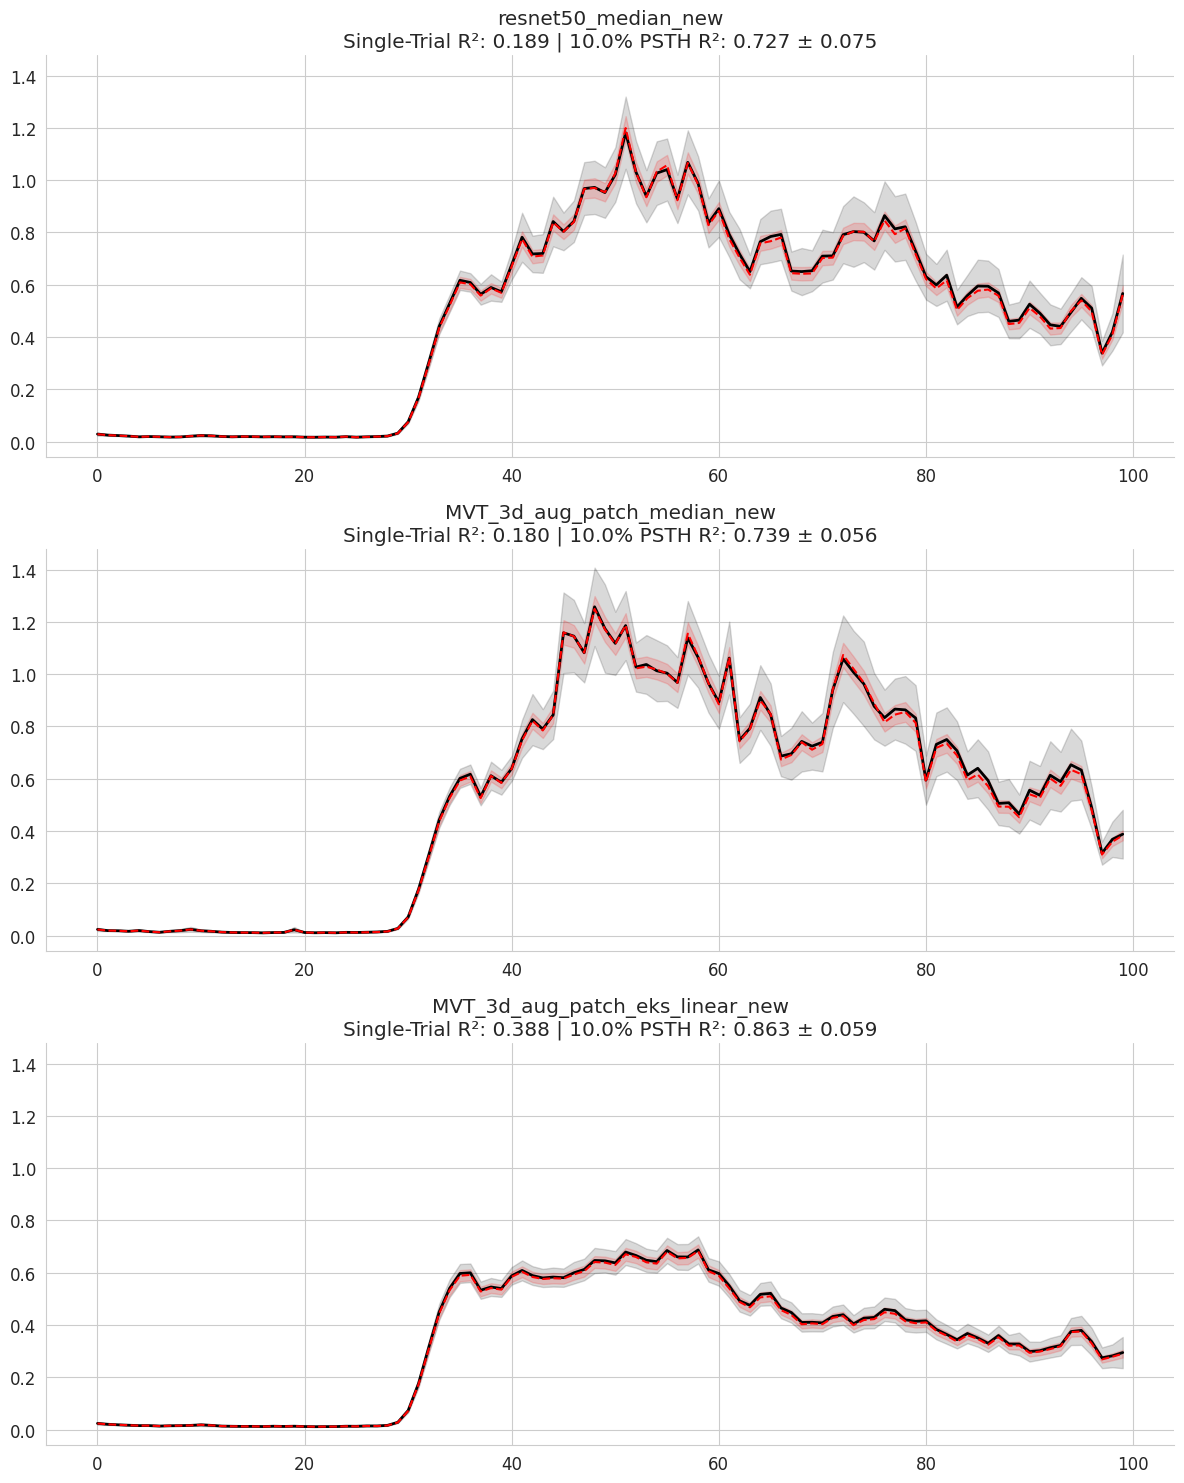

,model,r2_single_trial,psth_r2_10.0pct_mean,psth_r2_10.0pct_std,psth_evs_10.0pct_mean,correlation
0,resnet50_median_new,0.189312,0.727087,0.075363,0.742687,0.437821
1,MVT_3d_aug_patch_median_new,0.179680,0.739041,0.055954,0.753029,0.426793
2,MVT_3d_aug_patch_eks_linear_new,0.388160,0.863048,0.058812,0.868745,0.628215


In [159]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, explained_variance_score

def plot_session_psth_comparison_v3(base_path, eid, target, pose_models):
    n_models = len(pose_models)
    fig, axes = plt.subplots(n_models, 1, figsize=(12, 5 * n_models), sharey=True)
    if n_models == 1: axes = [axes]
    
    results = []
    
    for ax, m_name in zip(axes, pose_models):
        path = f"{base_path}/{eid}/{target}/{m_name}/linear/all/{eid}_cv.npy"
        if not os.path.exists(path):
            continue
        
        data = np.load(path, allow_pickle=True).item()
        y = data['all_test_y']
        pred = data['all_test_pred']
        n_trials = y.shape[0]
        print(f" the number of trials is: {n_trials}")
        print(f"n_trials: {n_trials}")

        # --- 1. Global Metrics ---
        r2_single = r2_score(y.flatten(), pred.flatten())
        corr_single = np.corrcoef(y.flatten(), pred.flatten())[0, 1]

        # --- 2. 5-Fold Subsampled PSTH (20% per fold) ---
        # Shuffle indices to ensure folds are random
        indices = np.arange(n_trials)
        np.random.shuffle(indices)
        pct = 0.1
        folds = np.array_split(indices, 100*pct) # Split into 5 groups of ~20%
        
        fold_r2s = []
        fold_evs = []
        
        for f_idx in folds:
            # Calculate PSTH for this 20% subset
            psth_y = np.mean(y[f_idx], axis=0)
            psth_p = np.mean(pred[f_idx], axis=0)
            
            fold_r2s.append(r2_score(psth_y, psth_p))
            # EVS is better if there is a slight scaling bias
            fold_evs.append(explained_variance_score(psth_y, psth_p))

        psth_r2_mean = np.mean(fold_r2s)
        psth_r2_std = np.std(fold_r2s)

        results.append({
            'model': m_name,
            'r2_single_trial': r2_single,
            f'psth_r2_{pct*100}pct_mean': psth_r2_mean,
            f'psth_r2_{pct*100}pct_std': psth_r2_std,
            f'psth_evs_{pct*100}pct_mean': np.mean(fold_evs),
            'correlation': corr_single
        })

        # --- 3. Visualization (using full session average for the plot) ---
        mean_y = np.mean(y, axis=0)
        mean_p = np.mean(pred, axis=0)
        sem_y = np.std(y, axis=0) / np.sqrt(n_trials)
        sem_p = np.std(pred, axis=0) / np.sqrt(n_trials)
        
        time_bins = np.arange(len(mean_y))
        ax.plot(time_bins, mean_y, color='black', label='Ground Truth', lw=2)
        ax.fill_between(time_bins, mean_y - sem_y, mean_y + sem_y, color='black', alpha=0.15)
        ax.plot(time_bins, mean_p, color='red', linestyle='--', label='Predicted', lw=1.5)
        ax.fill_between(time_bins, mean_p - sem_p, mean_p + sem_p, color='red', alpha=0.15)
        
        ax.set_title(f"{m_name}\nSingle-Trial R²: {r2_single:.3f} | {pct*100}% PSTH R²: {psth_r2_mean:.3f} ± {psth_r2_std:.3f}")
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()
    return pd.DataFrame(results)

plot_session_psth_comparison_v3(base_path,eid,target,pose_models)


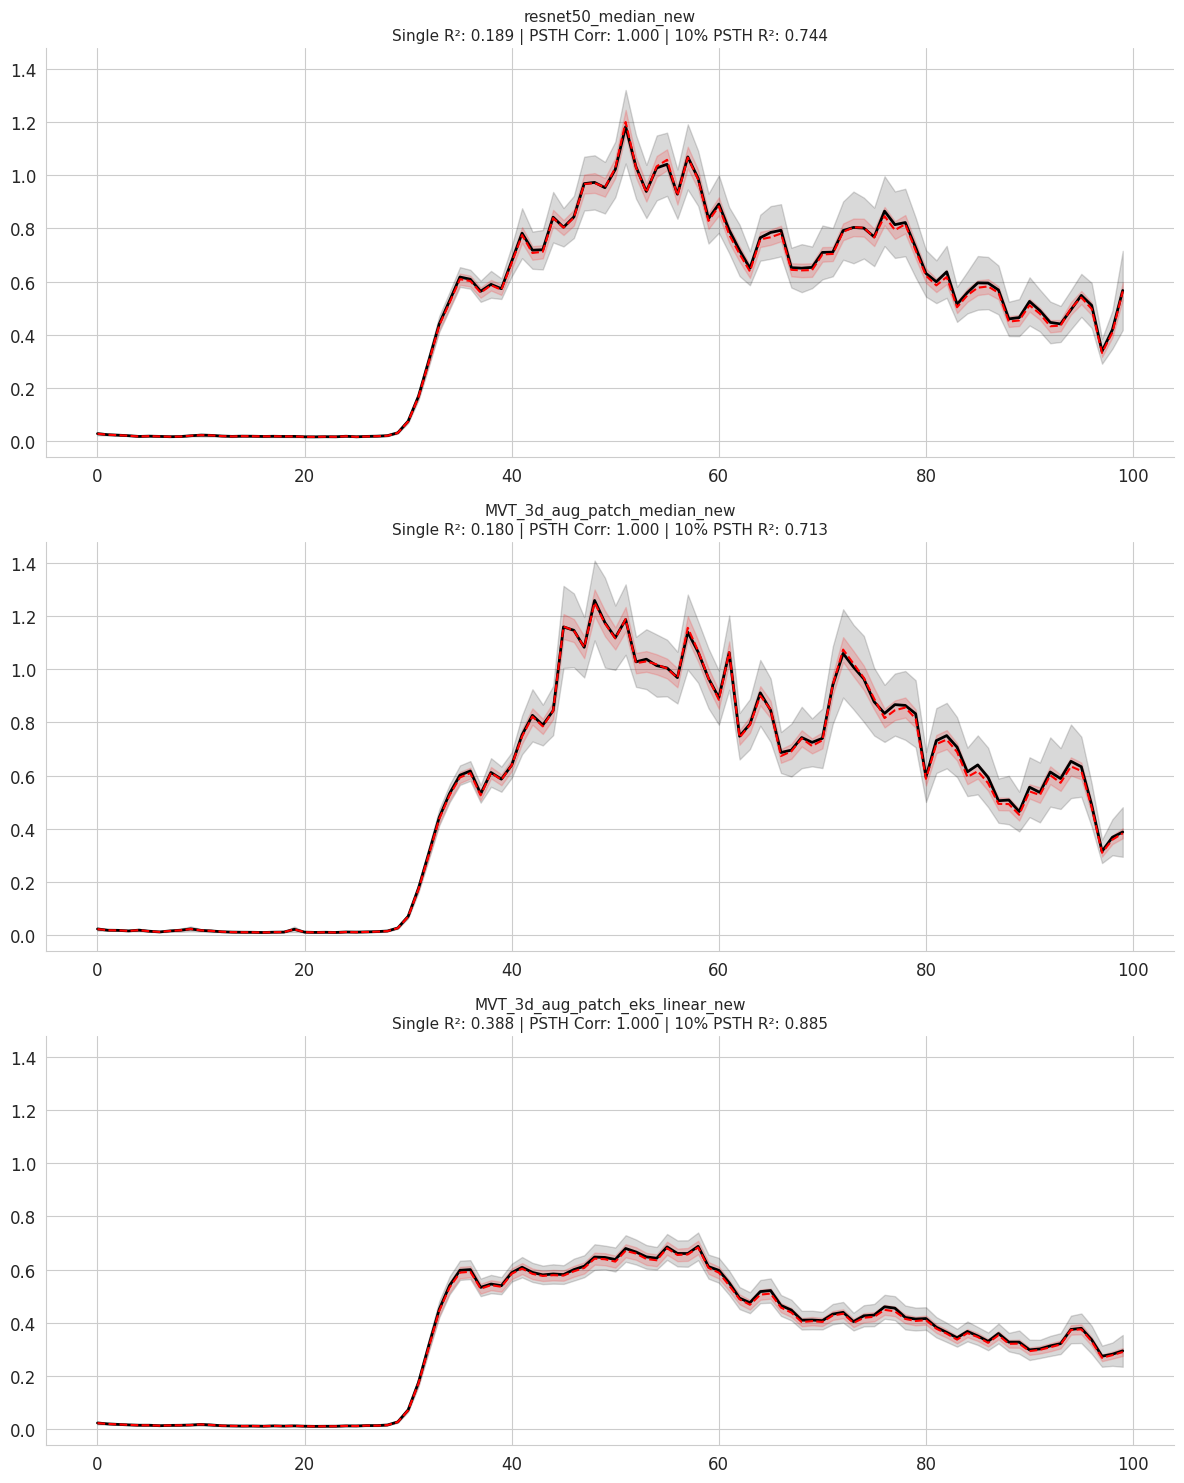

,model,r2_single_trial,corr_single_trial,psth_corr_all_trials,psth_r2_10pct_mean,psth_r2_10pct_std
0,resnet50_median_new,0.189312,0.437821,0.999838,0.743995,0.060290
1,MVT_3d_aug_patch_median_new,0.179680,0.426793,0.999827,0.713069,0.059501
2,MVT_3d_aug_patch_eks_linear_new,0.388160,0.628215,0.999966,0.885266,0.036143


In [160]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, explained_variance_score

def plot_session_psth_comparison_v3(base_path, eid, target, pose_models):
    n_models = len(pose_models)
    fig, axes = plt.subplots(n_models, 1, figsize=(12, 5 * n_models), sharey=True)
    if n_models == 1: axes = [axes]
    
    results = []
    
    for ax, m_name in zip(axes, pose_models):
        path = f"{base_path}/{eid}/{target}/{m_name}/linear/all/{eid}_cv.npy"
        if not os.path.exists(path):
            continue
        
        data = np.load(path, allow_pickle=True).item()
        y = data['all_test_y']
        pred = data['all_test_pred']
        n_trials = y.shape[0]

        # --- 1. Global Metrics (Single Trial) ---
        r2_single = r2_score(y.flatten(), pred.flatten())
        corr_single = np.corrcoef(y.flatten(), pred.flatten())[0, 1]

        # --- 2. Session-Wide PSTH Correlation (All Trials) ---
        mean_y = np.mean(y, axis=0)
        mean_p = np.mean(pred, axis=0)
        # Pearson correlation of the average traces
        psth_corr_all = np.corrcoef(mean_y, mean_p)[0, 1]

        # --- 3. Subsampled PSTH R² (e.g., 10% per fold) ---
        indices = np.arange(n_trials)
        np.random.shuffle(indices)
        pct = 0.1
        n_folds = int(1/pct) # e.g., 10 folds for 10%
        folds = np.array_split(indices, n_folds) 
        
        fold_r2s = []
        for f_idx in folds:
            psth_y_sub = np.mean(y[f_idx], axis=0)
            psth_p_sub = np.mean(pred[f_idx], axis=0)
            fold_r2s.append(r2_score(psth_y_sub, psth_p_sub))

        psth_r2_mean = np.mean(fold_r2s)
        psth_r2_std = np.std(fold_r2s)

        # Store results
        results.append({
            'model': m_name,
            'r2_single_trial': r2_single,
            'corr_single_trial': corr_single,
            'psth_corr_all_trials': psth_corr_all, # Added this
            f'psth_r2_{int(pct*100)}pct_mean': psth_r2_mean,
            f'psth_r2_{int(pct*100)}pct_std': psth_r2_std
        })

        # --- 4. Visualization ---
        sem_y = np.std(y, axis=0) / np.sqrt(n_trials)
        sem_p = np.std(pred, axis=0) / np.sqrt(n_trials)
        time_bins = np.arange(len(mean_y))
        
        ax.plot(time_bins, mean_y, color='black', label='Ground Truth', lw=2)
        ax.fill_between(time_bins, mean_y - sem_y, mean_y + sem_y, color='black', alpha=0.15)
        ax.plot(time_bins, mean_p, color='red', linestyle='--', label='Predicted', lw=1.5)
        ax.fill_between(time_bins, mean_p - sem_p, mean_p + sem_p, color='red', alpha=0.15)
        
        # Updated title to include the PSTH correlation
        ax.set_title(f"{m_name}\nSingle R²: {r2_single:.3f} | PSTH Corr: {psth_corr_all:.3f} | {int(pct*100)}% PSTH R²: {psth_r2_mean:.3f}", fontsize=11)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()
    return pd.DataFrame(results)

plot_session_psth_comparison_v3(base_path,eid,target,pose_models)


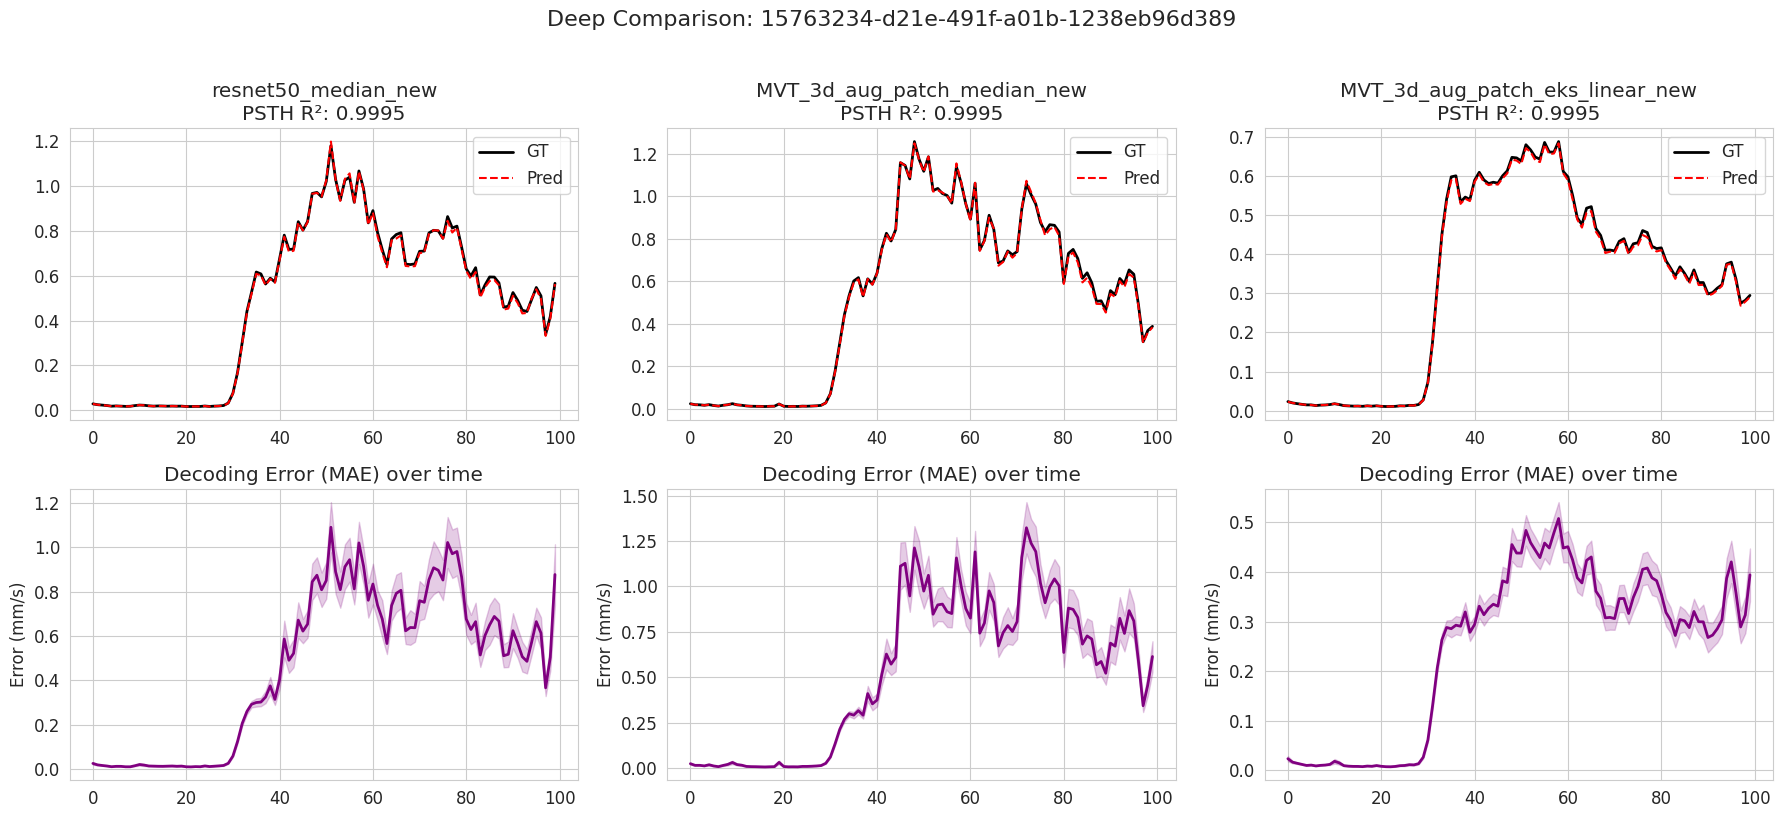

In [161]:
def plot_session_detailed_differences(base_path, eid, target, pose_models):
    n_models = len(pose_models)
    # Row 1: PSTH (Speed)
    # Row 2: Mean Absolute Error (The "Residuals")
    # Row 3: Distribution of Trial-by-Trial R2
    fig, axes = plt.subplots(2, n_models, figsize=(6 * n_models, 8), sharex='row')
    if n_models == 1: axes = [[ax] for ax in axes]

    for col_idx, m_name in enumerate(pose_models):
        path = f"{base_path}/{eid}/{target}/{m_name}/linear/all/{eid}_cv.npy"
        data = np.load(path, allow_pickle=True).item()
        y = data['all_test_y']
        pred = data['all_test_pred']
        
        # --- ROW 1: PSTH (Standard View) ---
        ax_psth = axes[0][col_idx]
        m_y, m_p = np.mean(y, axis=0), np.mean(pred, axis=0)
        ax_psth.plot(m_y, color='black', label='GT', lw=2)
        ax_psth.plot(m_p, color='red', linestyle='--', label='Pred', lw=1.5)
        ax_psth.set_title(f"{m_name}\nPSTH R²: {r2_score(m_y, m_p):.4f}")
        ax_psth.legend()

        # --- ROW 2: Mean Absolute Error (MAE) ---
        # This shows WHERE in the trial the decoder is struggling most
        ax_error = axes[1][col_idx]
        errors = np.abs(y - pred)
        mean_error = np.mean(errors, axis=0)
        sem_error = np.std(errors, axis=0) / np.sqrt(len(y))
        
        ax_error.plot(mean_error, color='purple', lw=2)
        ax_error.fill_between(range(100), mean_error - sem_error, mean_error + sem_error, color='purple', alpha=0.2)
        ax_error.set_title("Decoding Error (MAE) over time")
        ax_error.set_ylabel("Error (mm/s)")


    plt.suptitle(f"Deep Comparison: {eid}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the detailed comparison
plot_session_detailed_differences(base_path, eid, target, pose_models)


DETAILED PERFORMANCE SUMMARY: lightning-pose-pawR-3d-speed

MODEL STATISTICS (Mean ± STD):
                                      MAE           Correlation          
                                     mean       std        mean       std
Model                                                                    
MVT_3d_aug_patch_eks_linear_new  0.322107  0.235179    0.502611  0.062084
MVT_3d_aug_patch_median_new      0.454699  0.309062    0.438183  0.048868
resnet50_median_new              0.519168  0.352105    0.433871  0.059156

PAIRED STATISTICAL TESTS (Wilcoxon Signed-Rank):
n = 24 common sessions

>>> Hypothesis: MVT_3d_aug_patch_median_new is BETTER than resnet50_median_new
  One-sided p-val (Corr MVT_3d_aug_patch_median_new > resnet50_median_new): 4.7205e-01
  One-sided p-val (MAE MVT_3d_aug_patch_median_new < resnet50_median_new):  9.8689e-02
  Result: NOT SIGNIFICANT

>>> Hypothesis: MVT_3d_aug_patch_eks_linear_new is BETTER than resnet50_median_new
  One-sided p-val (Corr MVT

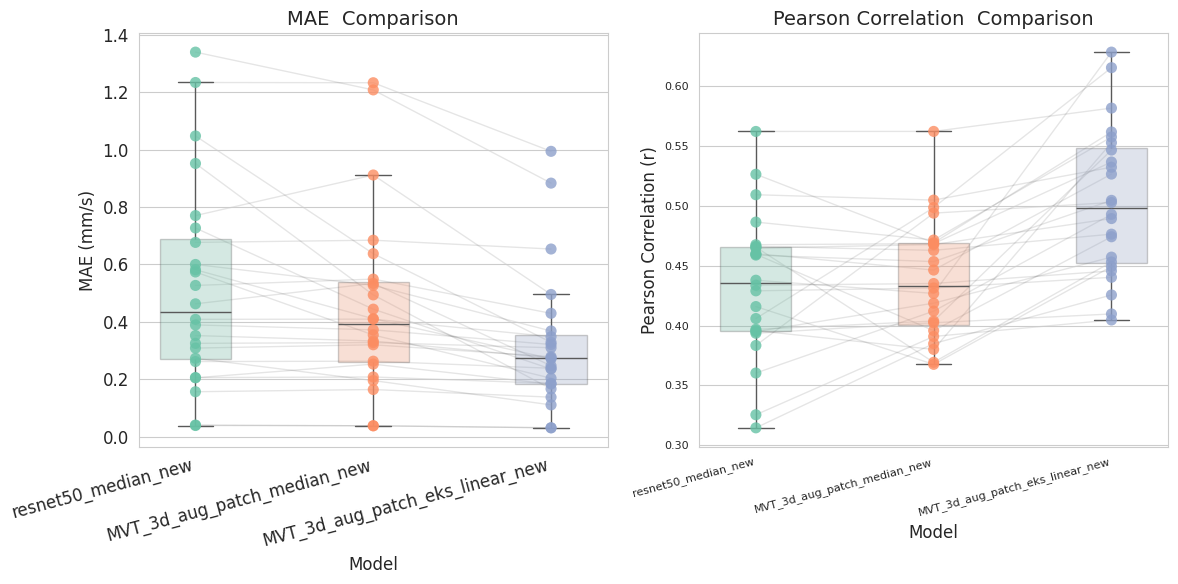

In [162]:
from scipy.stats import wilcoxon
from itertools import combinations

def plot_session_summary_with_detailed_stats(base_path, eids, target, pose_models):
    records = []
    for eid in eids:
        for m_name in pose_models:
            path = f"{base_path}/{eid}/{target}/{m_name}/linear/all/{eid}_cv.npy"
            if not os.path.exists(path): continue
            data = np.load(path, allow_pickle=True).item()
            y, pred = data['all_test_y'].flatten(), data['all_test_pred'].flatten()
            records.append({
                'Session': eid, 
                'Model': m_name, 
                'MAE': np.mean(np.abs(y - pred)), 
                'Correlation': np.corrcoef(y, pred)[0, 1]
            })
    
    df = pd.DataFrame(records)
    pivot_mae = df.pivot(index='Session', columns='Model', values='MAE').dropna()
    pivot_corr = df.pivot(index='Session', columns='Model', values='Correlation').dropna()
    available_models = [m for m in pose_models if m in pivot_mae.columns]

    # --- 1. PRINT NUMERICAL VALUES TO CONSOLE ---
    print(f"\n{'='*70}")
    print(f"DETAILED PERFORMANCE SUMMARY: {target}")
    print(f"{'='*70}")
    
    summary = df.groupby('Model')[['MAE', 'Correlation']].agg(['mean', 'std'])
    print("\nMODEL STATISTICS (Mean ± STD):")
    print(summary)

    # --- 2. MULTI-MODEL STATISTICAL TESTS ---
    if len(available_models) >= 2:
        print(f"\nPAIRED STATISTICAL TESTS (Wilcoxon Signed-Rank):")
        print(f"n = {len(pivot_mae)} common sessions")
        
        # Iterate through all possible pairs of models
        for m1, m2 in combinations(available_models, 2):
            print(f"\n>>> Hypothesis: {m2} is BETTER than {m1}")
            
            # 1. Correlation: Test if m2 > m1
            _, p_corr_one = wilcoxon(pivot_corr[m2], pivot_corr[m1], alternative='greater')
            
            # 2. MAE: Test if m2 < m1
            _, p_mae_one = wilcoxon(pivot_mae[m2], pivot_mae[m1], alternative='less')
            
            print(f"  One-sided p-val (Corr {m2} > {m1}): {p_corr_one:.4e}")
            print(f"  One-sided p-val (MAE {m2} < {m1}):  {p_mae_one:.4e}")
            
            # Add a significance indicator for quick reading
            sig = "SIGNIFICANT" if p_corr_one < 0.05 else "NOT SIGNIFICANT"
            print(f"  Result: {sig}")
    print(f"{'='*70}\n")

    # --- 3. GENERATE PLOTS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    metrics = ['MAE', 'Correlation']
    axes = [ax1, ax2]
    ylabels = ["MAE (mm/s)", "Pearson Correlation (r)"]
    # font of the x-axis labels
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    pivots = [pivot_mae, pivot_corr]

    for ax, metric, ylabel, p_df in zip(axes, metrics, ylabels, pivots):
        # Fix for the FutureWarning: assign hue=Model
        sns.boxplot(data=df, x='Model', y=metric, hue='Model', ax=ax, palette='Set2', 
                    showfliers=False, width=0.4, boxprops=dict(alpha=0.3), legend=False)
        sns.stripplot(data=df, x='Model', y=metric, hue='Model', ax=ax, palette='Set2', 
                      size=8, alpha=0.8, jitter=False, legend=False)
        
        # Draw Connecting Lines for all models
        x_coords = range(len(available_models))
        for _, row in p_df.iterrows():
            ax.plot(x_coords, [row[m] for m in available_models], color='black', alpha=0.1, lw=1, zorder=0)

        ax.set_title(f"{ylabel.split('(')[0]} Comparison", fontsize=14)
        ax.set_ylabel(ylabel)
        plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

    plt.tight_layout()
    plt.show()

# Execute
plot_session_summary_with_detailed_stats(base_path, eids, target, pose_models)

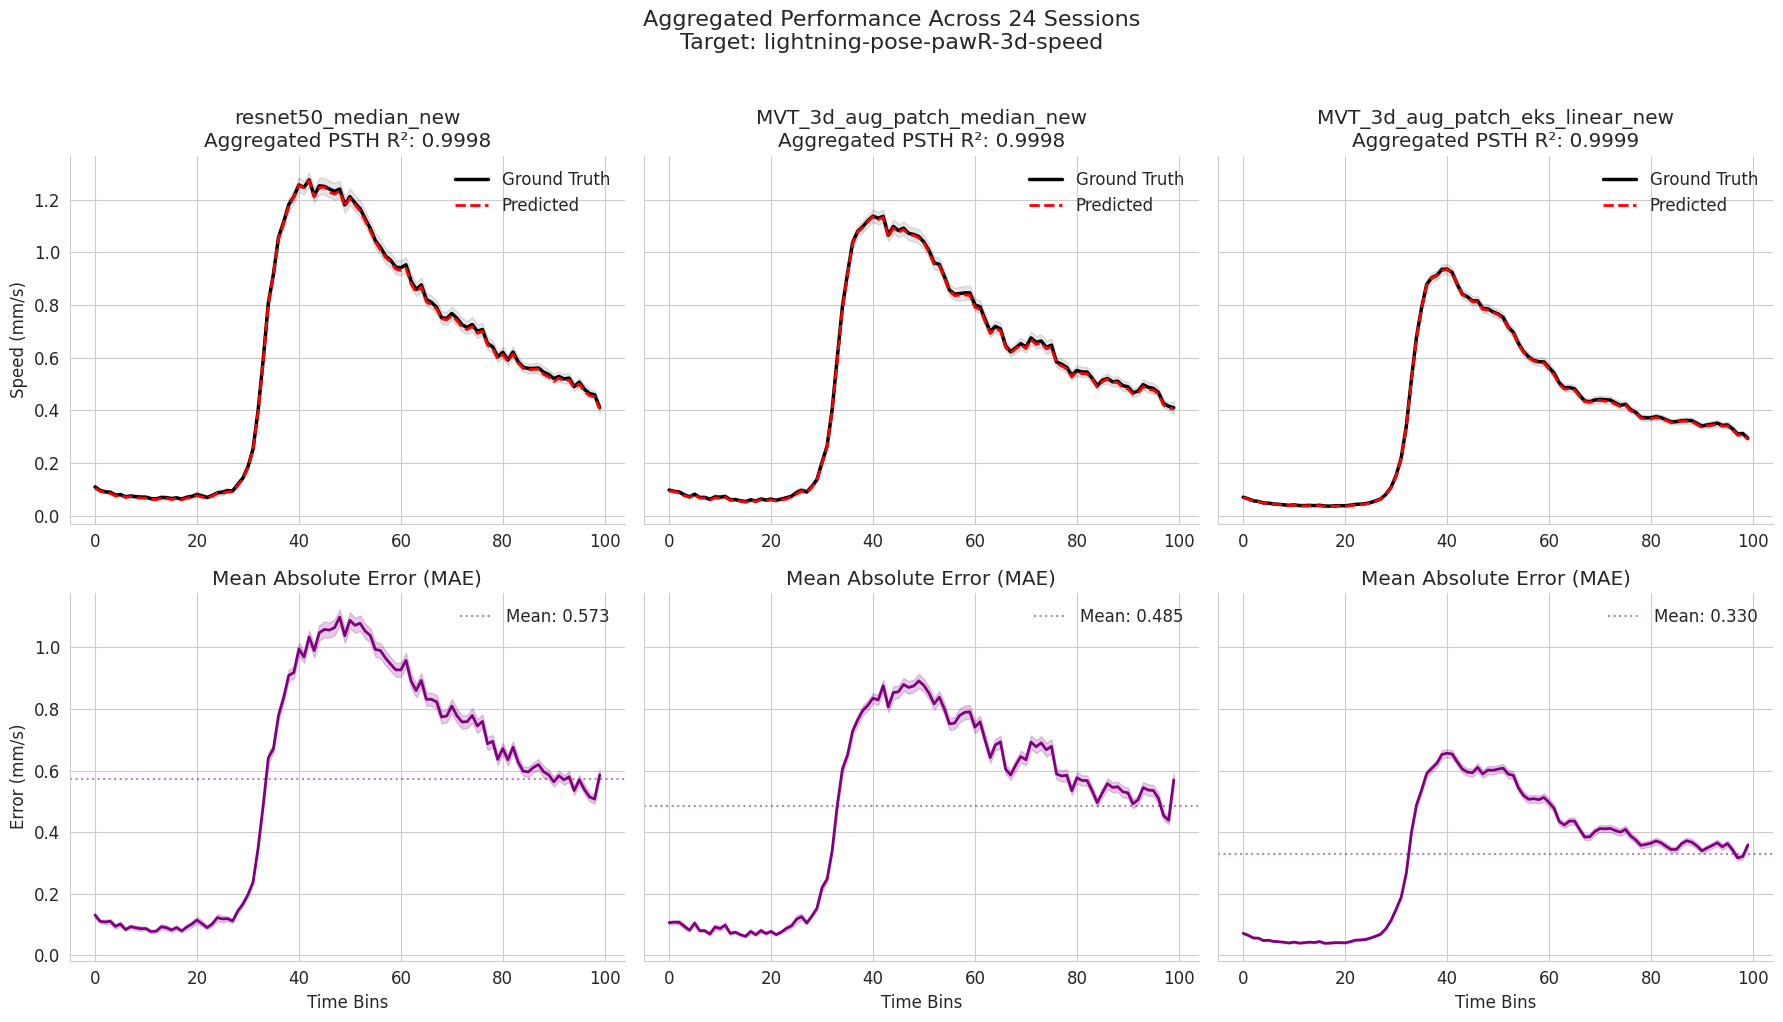

In [163]:
def plot_aggregated_psth_and_error(base_path, eids, target, pose_models):
    """
    Aggregates all trials from all sessions to show:
    1. Global PSTH (Speed)
    2. Global Decoding Error (MAE)
    """
    n_models = len(pose_models)
    fig, axes = plt.subplots(2, n_models, figsize=(6 * n_models, 10), sharex='row', sharey='row')
    if n_models == 1: axes = [[ax] for ax in axes]

    for col_idx, m_name in enumerate(pose_models):
        all_y = []
        all_p = []
        
        # Load and stack all sessions
        for eid in eids:
            path = f"{base_path}/{eid}/{target}/{m_name}/linear/all/{eid}_cv.npy"
            if not os.path.exists(path): continue
            
            d = np.load(path, allow_pickle=True).item()
            all_y.append(d['all_test_y'])
            all_p.append(d['all_test_pred'])
            
        if not all_y: continue
        
        # Stack into (Total Trials, 100)
        Y_STACK = np.vstack(all_y)
        P_STACK = np.vstack(all_p)
        
        # --- ROW 1: AGGREGATED PSTH ---
        ax_psth = axes[0][col_idx]
        m_y = np.mean(Y_STACK, axis=0)
        m_p = np.mean(P_STACK, axis=0)
        s_y = np.std(Y_STACK, axis=0) / np.sqrt(len(Y_STACK))
        
        ax_psth.plot(m_y, color='black', label='Ground Truth', lw=2.5)
        ax_psth.fill_between(range(100), m_y - s_y, m_y + s_y, color='black', alpha=0.1)
        ax_psth.plot(m_p, color='red', linestyle='--', label='Predicted', lw=2)
        
        psth_r2 = r2_score(m_y, m_p)
        ax_psth.set_title(f"{m_name}\nAggregated PSTH R²: {psth_r2:.4f}")
        if col_idx == 0: ax_psth.set_ylabel("Speed (mm/s)")
        ax_psth.legend(frameon=False)

        # --- ROW 2: AGGREGATED ERROR (MAE) ---
        # This shows the "residual noise" over time
        ax_err = axes[1][col_idx]
        abs_errors = np.abs(Y_STACK - P_STACK)
        m_err = np.mean(abs_errors, axis=0)
        s_err = np.std(abs_errors, axis=0) / np.sqrt(len(abs_errors))
        
        ax_err.plot(m_err, color='purple', lw=2)
        ax_err.fill_between(range(100), m_err - s_err, m_err + s_err, color='purple', alpha=0.2)
        
        # Add a horizontal line for the baseline error (average error across all time)
        ax_err.axhline(np.mean(m_err), color='purple', linestyle=':', alpha=0.5, label=f'Mean: {np.mean(m_err):.3f}')
        
        ax_err.set_title("Mean Absolute Error (MAE)")
        ax_err.set_xlabel("Time Bins")
        if col_idx == 0: ax_err.set_ylabel("Error (mm/s)")
        ax_err.legend(frameon=False)
        
        sns.despine(ax=ax_psth)
        sns.despine(ax=ax_err)

    plt.suptitle(f"Aggregated Performance Across {len(eids)} Sessions\nTarget: {target}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the aggregated analysis
plot_aggregated_psth_and_error(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawR-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.173
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawR-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.135
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawR-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.200
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

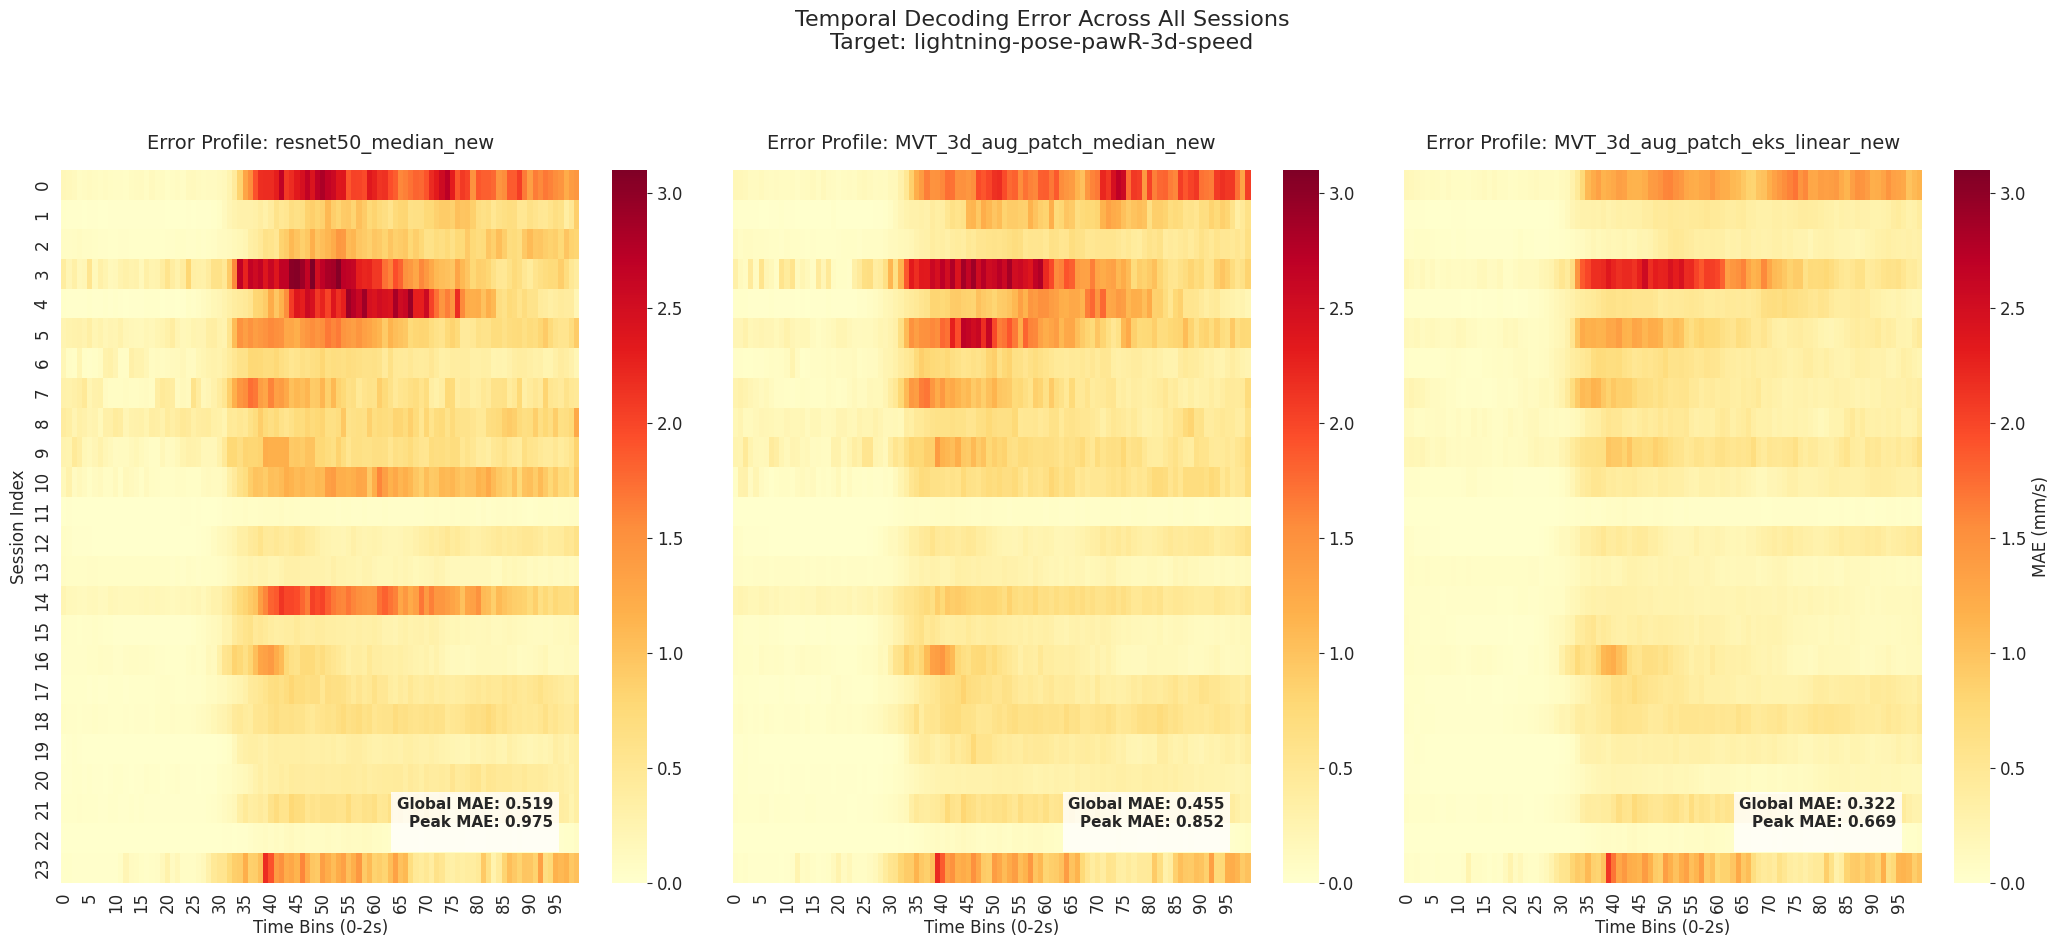

In [164]:
def plot_error_heatmap_across_sessions(base_path, eids, target, pose_models):
    """
    Plots MAE heatmaps with shared color scale and summary statistics.
    """
    n_models = len(pose_models)
    model_data = {m: [] for m in pose_models}
    global_max = 0
    
    # 1. Collect Data
    for eid in eids:
        for m_name in pose_models:
            res_dict = load_session_results(base_path, eid, target, [m_name])
            if m_name in res_dict:
                err = np.mean(np.abs(res_dict[m_name]['test_y'] - res_dict[m_name]['test_pred']), axis=0)
                model_data[m_name].append(err)
                global_max = max(global_max, np.max(err))
    
    # 2. Plot
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 9), sharey=True)
    if n_models == 1: axes = [axes]
    
    for i, m_name in enumerate(pose_models):
        ax = axes[i]
        data = np.array(model_data[m_name])
        if len(data) == 0: continue
            
        # Summary Statistics
        avg_mae = np.mean(data)
        peak_mae = np.max(np.mean(data, axis=0))
        session_variability = (np.std(np.mean(data, axis=1)) / avg_mae) * 100 # Coefficient of Variation %

        # Heatmap
        sns.heatmap(data, ax=ax, cmap='YlOrRd', vmin=0, vmax=global_max, 
                    cbar_kws={'label': 'MAE (mm/s)'} if i == n_models-1 else {})
        
        # Add Text Box with Numbers
        stats_text = (f"Global MAE: {avg_mae:.3f}\n"
                      f"Peak MAE: {peak_mae:.3f}\n")
        
        # Place text box in the bottom right of each heatmap
        ax.text(0.95, 0.05, stats_text, transform=ax.transAxes, 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'),
                fontsize=11, fontweight='bold', ha='right', va='bottom')

        ax.set_title(f"Error Profile: {m_name}", fontsize=14, pad=15)
        ax.set_xlabel("Time Bins (0-2s)", fontsize=12)
        if i == 0: ax.set_ylabel("Session Index", fontsize=12)

    plt.suptitle(f"Temporal Decoding Error Across All Sessions\nTarget: {target}", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# Run the enhanced heatmap
plot_error_heatmap_across_sessions(base_path, eids, target, pose_models)

In [70]:
def plot_shuffled_baseline_comparison(base_path, eids, target, pose_models):
    """
    Compares actual R2 to a shuffled baseline to prove the decoding is real.
    """
    records = []
    
    for eid in eids:
        for m_name in pose_models:
            res_dict = load_session_results(base_path, eid, target, [m_name])
            if m_name not in res_dict: continue
            
            y = res_dict[m_name]['test_y']
            pred = res_dict[m_name]['test_pred']
            
            # 1. Actual R2
            actual_r2 = r2_score(y.flatten(), pred.flatten())
            records.append({'Model': m_name, 'Type': 'Actual', 'R2': actual_r2, 'Session': eid})
            
            # 2. Shuffled R2 (Shuffle trial order)
            y_shuffled = y[np.random.permutation(len(y))]
            shuffled_r2 = r2_score(y_shuffled.flatten(), pred.flatten())
            records.append({'Model': m_name, 'Type': 'Shuffled', 'R2': shuffled_r2, 'Session': eid})

    df = pd.DataFrame(records)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x='Model', y='R2', hue='Type', palette=['#3498db', '#95a5a6'], capsize=.1)
    sns.stripplot(data=df, x='Model', y='R2', hue='Type', dodge=True, alpha=0.3, palette=['#2980b9', '#7f8c8d'])
    
    plt.title(f"Decoding Significance: Actual vs. Shuffled Baseline\nTarget: {target}")
    plt.ylabel("Flattened R²")
    plt.axhline(0, color='black', lw=1)
    plt.legend(title="Data Type")
    sns.despine()
    plt.show()

# Run the significance test
plot_shuffled_baseline_comparison(base_path, eids, target, pose_models)

KeyError: 'test_y'

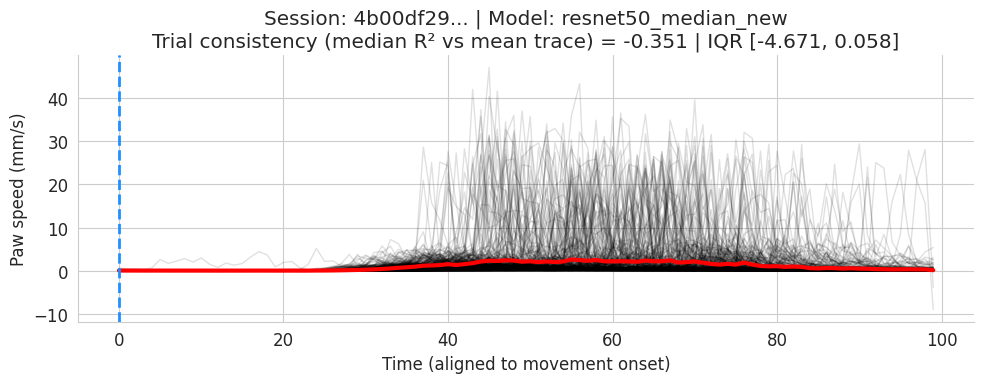

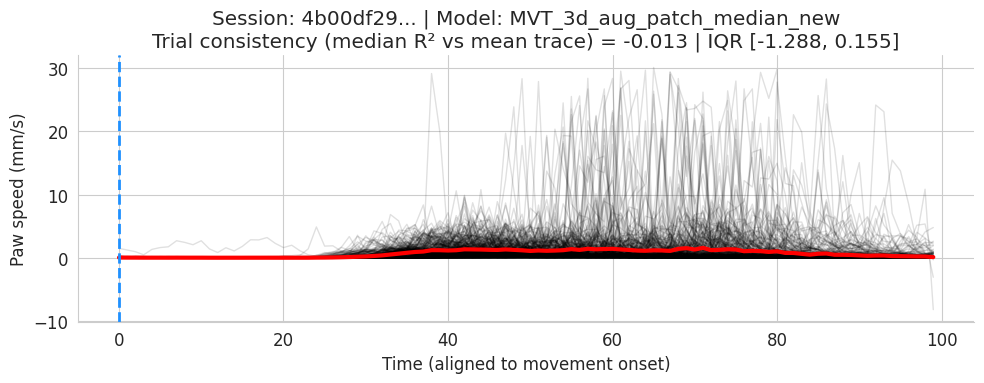

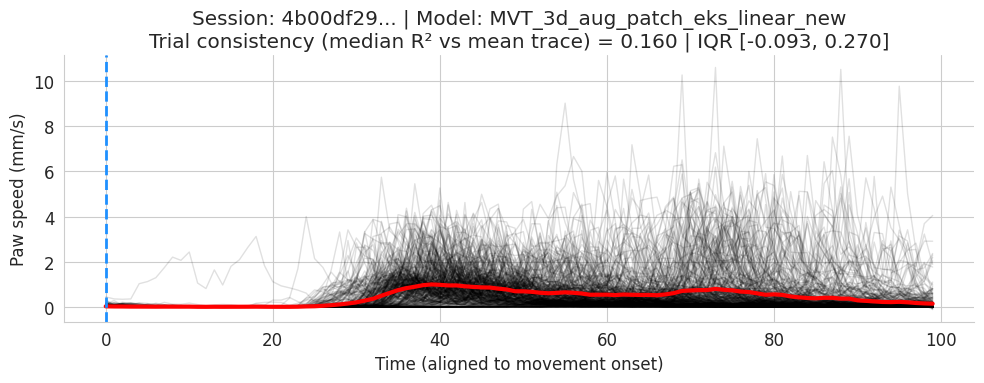

In [131]:
import numpy as np
import matplotlib.pyplot as plt

def trial_consistency_r2(y: np.ndarray):
    """
    Trial consistency = how well the mean trace across trials explains each trial.

    Args:
        y: array (n_trials, T)

    Returns:
        r2_trials: array (n_trials,)
        r2_median: float
        r2_iqr: (q25, q75)
        mean_trace: array (T,)
    """
    y = np.asarray(y)
    if y.ndim != 2:
        raise ValueError(f"y must be 2D (n_trials, T), got {y.shape}")

    n_trials, T = y.shape
    mean_trace = y.mean(axis=0)

    # SSE_i: error to mean trace
    sse = np.sum((y - mean_trace[None, :]) ** 2, axis=1)

    # SST_i: variance within each trial around its own mean over time
    y_trial_mean = y.mean(axis=1, keepdims=True)
    sst = np.sum((y - y_trial_mean) ** 2, axis=1)

    # Handle low-variance trials safely (sst ~ 0 => R2 undefined)
    eps = 1e-12
    valid = sst > eps
    r2_trials = np.full(n_trials, np.nan)
    r2_trials[valid] = 1.0 - (sse[valid] / sst[valid])

    r2_median = np.nanmedian(r2_trials)
    q25, q75 = np.nanpercentile(r2_trials, [25, 75])

    return r2_trials, r2_median, (q25, q75), mean_trace


def plot_trial_consistency(
    y: np.ndarray,
    time: np.ndarray = None,
    event_time: float = 0.0,
    title: str = "",
    ylabel: str = "Paw speed (mm/s)",
    alpha_trials: float = 0.12,
    lw_trials: float = 1.0,
    lw_mean: float = 3.0,
):
    """
    Panel E-style plot: gray single trials + red mean trace + trial consistency score.
    """
    y = np.asarray(y)
    n_trials, T = y.shape

    if time is None:
        time = np.arange(T)
    else:
        time = np.asarray(time)
        if time.shape[0] != T:
            raise ValueError(f"time length {time.shape[0]} != T {T}")

    r2_trials, r2_med, (q25, q75), mean_trace = trial_consistency_r2(y)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))

    # single trials
    for i in range(n_trials):
        ax.plot(time, y[i], color="black", alpha=alpha_trials, lw=lw_trials)

    # mean trace
    ax.plot(time, mean_trace, color="red", lw=lw_mean)

    # event line
    ax.axvline(event_time, color="dodgerblue", linestyle="--", lw=2)

    ax.set_title(
        (title + "\n" if title else "") +
        f"Trial consistency (median R² vs mean trace) = {r2_med:.3f} | IQR [{q25:.3f}, {q75:.3f}]"
    )
    ax.set_xlabel("Time (aligned to movement onset)")
    ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    return fig, ax

# Example usage:
# Load your data first (replace with actual data loading)
# Run trial consistency analysis for all models
for i, test_model in enumerate(pose_models):
    test_eid = eids[4]
    results_path = f"{base_path}/{test_eid}/{target}/{test_model}/linear/all/{test_eid}_cv.npy"
    
    try:
        data = np.load(results_path, allow_pickle=True).item()
        y = data['all_test_y']

        # Then run the analysis:
        fig, ax = plot_trial_consistency(
            y=y,
            title=f"Session: {test_eid[:8]}... | Model: {test_model}",
            ylabel="Paw speed (mm/s)"
        )
        plt.show()
    except FileNotFoundError:
        print(f"File not found: {results_path}")
    except Exception as e:
        print(f"Error loading {test_model}: {e}")

# Or just get the consistency metrics:
# r2_trials, r2_median, (q25, q75), mean_trace = trial_consistency_r2(y)
# print(f"Trial consistency R² median: {r2_median:.3f}, IQR: [{q25:.3f}, {q75:.3f}]")



In [680]:
# Replace with one of your actual EIDs and models from the plot
test_eid = eids[0] 
test_model = pose_models[0]
results_path = f"{base_path}/{test_eid}/{target}/{test_model}/linear/all/{test_eid}_cv.npy"

data = np.load(results_path, allow_pickle=True).item()
y = data['all_test_y']
pred = data['all_test_pred']

print(f"Checking file: {results_path}")
print(f"Shape Y: {y.shape}, Shape Pred: {pred.shape}")
print(f"Are they the exact same object in memory? {y is pred}")
print(f"Are all values identical? {np.array_equal(y, pred)}")
if not np.array_equal(y, pred):
    print(f"Max difference: {np.max(np.abs(y - pred))}")

Checking file: /media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results/15b69921-d471-4ded-8814-2adad954bcd8/lightning-pose-pawL-3d-speed/resnet50_median_new/linear/all/15b69921-d471-4ded-8814-2adad954bcd8_cv.npy
Shape Y: (390, 100), Shape Pred: (390, 100)
Are they the exact same object in memory? False
Are all values identical? False
Max difference: 48.03333068938329


# From here this is for 1 session

In [659]:
results = load_session_results(base_path, eid, target, pose_models,model_method=model)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.227
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords



--- resnet50_median_new Per-Bin R² Summary ---
  First bin (0ms):  -0.0188
  Middle bin (1s):  0.1532
  Last bin (2s):    0.0679
  Mean of all bins: 0.0862

--- MVT_3d_aug_patch_median_new Per-Bin R² Summary ---
  First bin (0ms):  -0.0036
  Middle bin (1s):  0.1822
  Last bin (2s):    0.0482
  Mean of all bins: 0.1177


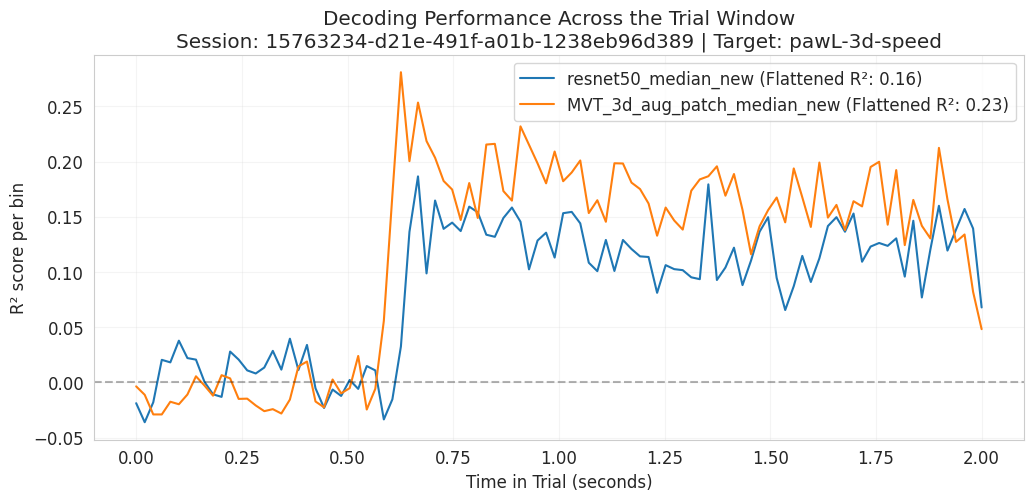

In [660]:
def analyze_per_bin_performance(results, pose_models):
    """
    Calculates and prints/plots R^2 for every time bin (0-100) for each model.
    """
    plt.figure(figsize=(12, 5))
    
    for model_name in pose_models:
        res = results[model_name]
        y_true = res['test_y']     # Shape: [n_trials, n_bins]
        y_pred = res['test_pred']   # Shape: [n_trials, n_bins]
        
        n_bins = y_true.shape[1]
        bin_r2s = []
        
        print(f"\n--- {model_name} Per-Bin R² Summary ---")
        for b in range(n_bins):
            # Calculate R2 for this specific bin across all trials
            r2 = r2_score(y_true[:, b], y_pred[:, b])
            bin_r2s.append(r2)
        
        # Print a few example bins
        print(f"  First bin (0ms):  {bin_r2s[0]:.4f}")
        print(f"  Middle bin (1s):  {bin_r2s[n_bins//2]:.4f}")
        print(f"  Last bin (2s):    {bin_r2s[-1]:.4f}")
        print(f"  Mean of all bins: {np.mean(bin_r2s):.4f}")
        
        # Plot the curve
        plt.plot(np.linspace(0, 2, n_bins), bin_r2s, label=f"{model_name} (Flattened R²: {res['r2']:.2f})")

    plt.axhline(0, color='black', linestyle='--', alpha=0.3)
    plt.xlabel("Time in Trial (seconds)")
    plt.ylabel("R² score per bin")
    target_without = target.replace("lightning-pose-", "")
    plt.title(f"Decoding Performance Across the Trial Window\nSession: {eid} | Target: {target_without}")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# Run the analysis
analyze_per_bin_performance(results, pose_models)

In [661]:
results

{'resnet50_median_new': {'test_y': array([[ 0.08634448,  0.19071575,  0.09016812, ...,  0.11352185,
           0.0442964 ,  0.00868268],
         [ 1.62904774,  0.32985378,  1.15222909, ...,  0.90803537,
           1.14982923, -0.66829859],
         [ 0.12578654,  0.21151392,  0.13428233, ...,  0.01516295,
           0.01665746,  0.24983134],
         ...,
         [ 0.00677589,  0.00889583,  0.01184305, ...,  0.02084097,
           0.03208493, -0.01017779],
         [ 0.02622122,  0.05352055,  0.05870071, ...,  0.01783859,
           0.02913367,  0.05088002],
         [ 0.00249746,  0.00987703,  0.0113642 , ...,  0.01197422,
           0.01049752,  0.00580128]]),
  'test_pred': array([[ 0.34398634,  0.22875111,  0.14848144, ...,  0.12063471,
           0.48345906,  1.10038519],
         [ 0.24853443,  0.01346689,  0.12160779, ...,  0.55335345,
           0.42759719,  1.38698299],
         [ 0.28180731,  0.22439205,  0.19033904, ...,  0.12526219,
           0.32736283,  0.85055957],
  

In [662]:
# Define colors for each pose model
# Darker color for pose model (ground truth), lighter for decoded prediction
colors = {
    # 'MVT_patch_masking_median': {
    #     'pose': '#1f77b4',      # Dark blue
    #     'decoded': '#aec7e8'    # Light blue
    # },
    'MVT_3d_aug_patch_median': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_median': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    },

    'MVT_3d_aug_patch_median_new': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_median_new': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    },

    # 'MVT_3d_aug_patch_eks': {
    #     'pose': 'green',      
    #     'decoded': 'lightgreen'    
    # },

    'MVT_3d_aug_patch_eks_linear': {
        'pose': 'green',      
        'decoded': 'lightgreen'    
    },

    'MVT_3d_aug_patch_0': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_0': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    }
}

(<Figure size 1400x1500 with 5 Axes>,
 array([<Axes: title={'center': 'pawL-3d-speed- Session: 15763234-d21e-491f-a01b-1238eb96d389 | Window: 0-800'}, ylabel='Speed (pix/s)'>,
        <Axes: ylabel='Avg Ensemble Var'>, <Axes: ylabel='X-3D'>,
        <Axes: ylabel='Y-3D'>,
        <Axes: xlabel='Time (seconds) & Video Frame Index', ylabel='Z-3D'>],
       dtype=object))

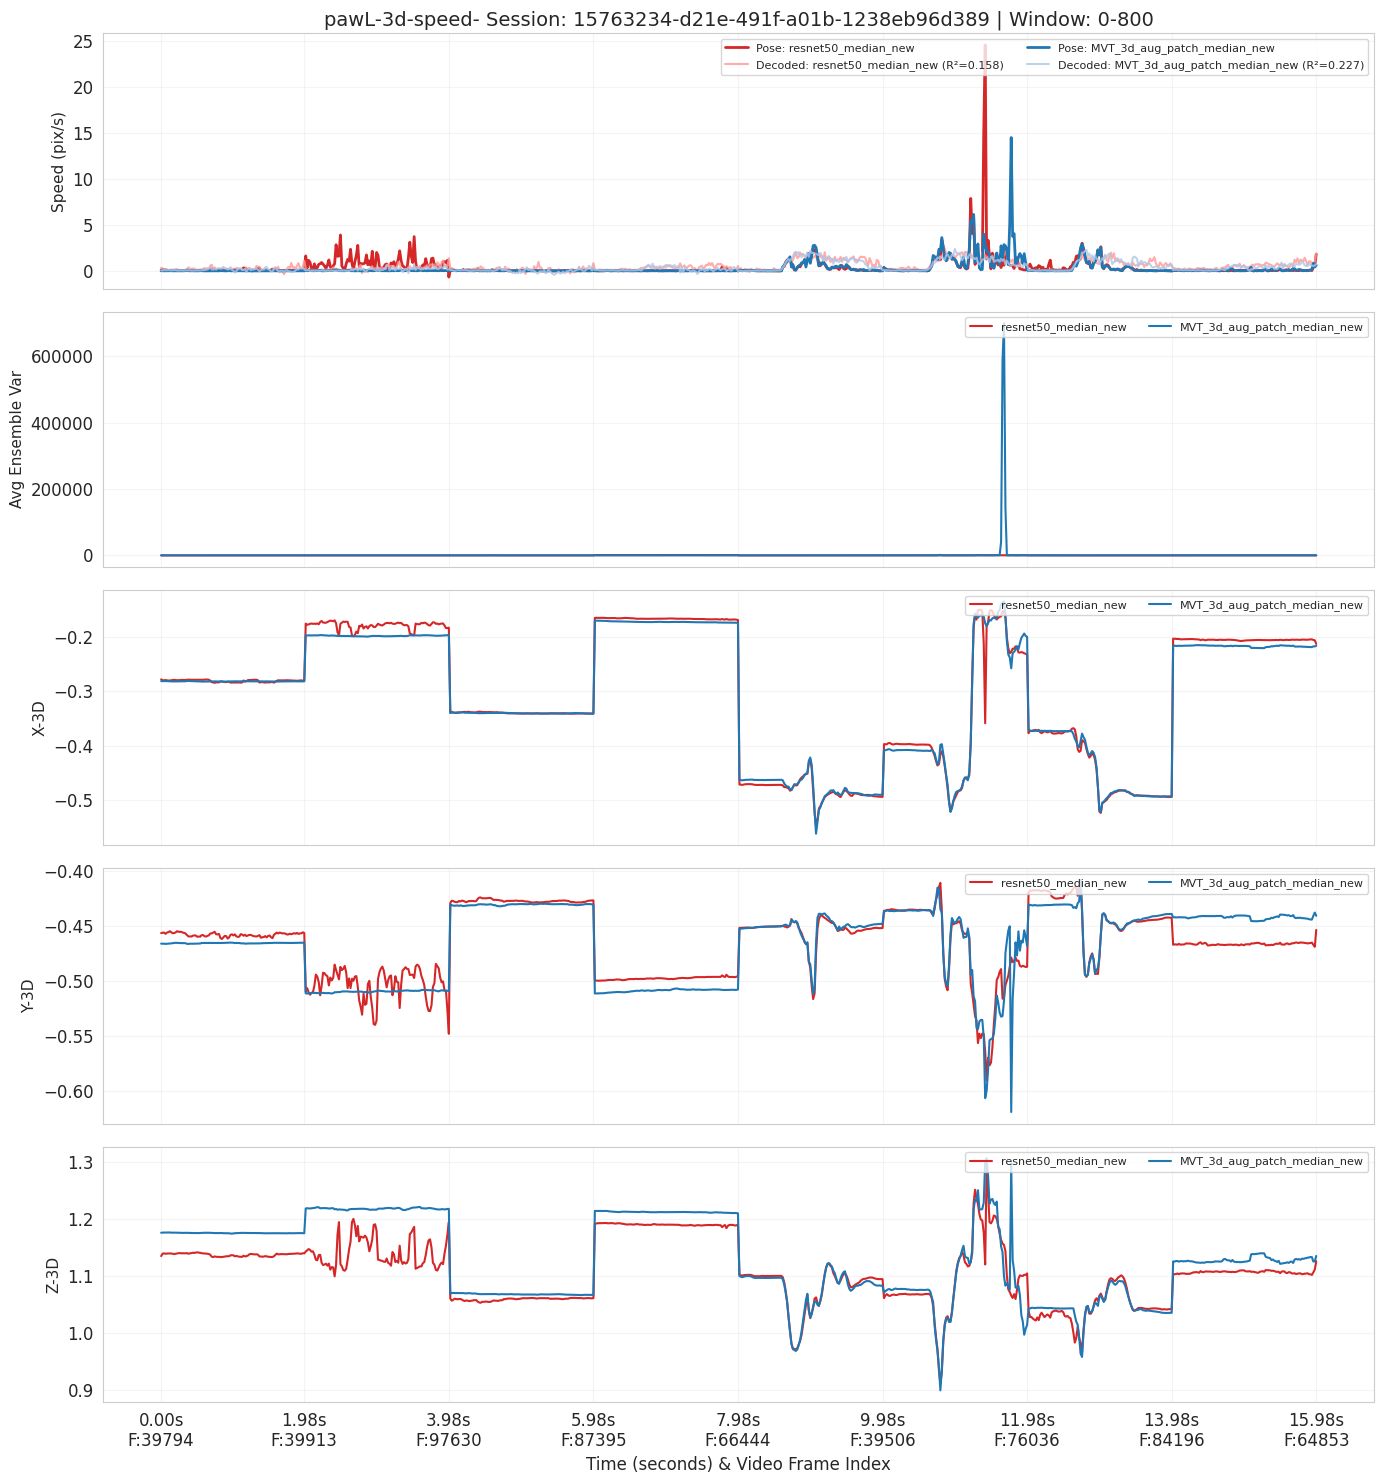

In [670]:
def plot_pose_results(results, pose_models, colors, eid, 
                      plots_to_show=None, 
                      start_time=0, 
                      end_time=800, 
                      sampling_rate=0.02,
                      target=target):
    
    # --- 1. LOAD MAPPING METADATA ---
    common_data_path = Path("/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/ibl_aligned") / eid
    alignment_info = np.load(common_data_path / "alignment_info.npy", allow_pickle=True).item()
    trial_intervals = alignment_info["trial_intervals"] 
    timestamp_file = Path("/media/lenny-aharon/T7/ibl-mouse/timestamps") / f"_ibl_leftCamera.times.{eid}.npy"
    frame_times = np.load(timestamp_file)
    
    orig_trial_ids = results[pose_models[0]]['test_original_trial_ids']
    trial_len_bins = 100 

    # --- 2. UPDATED PLOT CONFIG ---
    # We map the keys we added in the loader to user-friendly labels
    plot_config = {
        'speed': {'label': 'Speed (pix/s)', 'data_key': 'y_flattened'},
        'avg_var': {'label': 'Avg Ensemble Var', 'data_key': 'avg_ens_var_flattened'}, # <--- USE THIS
        'x_3d': {'label': 'X-3D', 'data_key': 'x_3d_flattened'},
        'y_3d': {'label': 'Y-3D', 'data_key': 'y_3d_flattened'},
        'z_3d': {'label': 'Z-3D', 'data_key': 'z_3d_flattened'}
    }

    if plots_to_show is None:
        plots_to_show = list(plot_config.keys())

    num_plots = len(plots_to_show)
    fig, axes = plt.subplots(num_plots, 1, figsize=(14, 3 * num_plots), sharex=True)
    if num_plots == 1: axes = [axes]

    for i, plot_key in enumerate(plots_to_show):
        ax = axes[i]
        config = plot_config.get(plot_key, {'label': plot_key, 'data_key': f"{plot_key}_flattened"})
        
        for pose_model in pose_models:
            res = results[pose_model]
            color_pose = colors[pose_model]['pose']
            
            if plot_key == 'speed':
                ax.plot(res['y_flattened'][start_time:end_time], color=color_pose, linewidth=2, label=f"Pose: {pose_model}")
                ax.plot(res['pred_flattened'][start_time:end_time], color=colors[pose_model]['decoded'], linewidth=1.5, 
                        label=f"Decoded: {pose_model} (R²={res['r2']:.3f})", alpha=0.8)
            else:
                # General plotting for all coordinate and variance keys
                data = res.get(config['data_key'])
                if data is not None:
                    ax.plot(data[start_time:end_time], color=color_pose, label=f"{pose_model}")

        ax.set_ylabel(config['label'], fontsize=11)
        ax.legend(fontsize=8, loc='upper right', ncol=2)
        ax.grid(True, alpha=0.2)

    # --- 3. DYNAMIC X-AXIS WITH VIDEO FRAMES ---
    duration_frames = end_time - start_time
    tick_indices = np.linspace(0, duration_frames - 1, 9, dtype=int)
    time_labels, frame_labels = [], []

    for idx in tick_indices:
        global_idx = start_time + idx
        time_labels.append(f"{(global_idx * sampling_rate):.2f}s")
        
        # trial_idx_in_test = global_idx // trial_len_bins
        # bin_within_trial = global_idx % trial_len_bins
        
        # if trial_idx_in_test < len(orig_trial_ids):
        #     orig_id = orig_trial_ids[trial_idx_in_test]
        #     bin_time = trial_intervals[orig_id][0] + (bin_within_trial * sampling_rate)
        #     video_frame = np.searchsorted(frame_times, bin_time)
        #     frame_labels.append(f"F:{video_frame}")
        # else:
        #     frame_labels.append("")

         # --- Inside the dynamic X-axis loop ---
        trial_idx_in_test = global_idx // trial_len_bins
        bin_within_trial = global_idx % trial_len_bins
        
        # ADD THIS CHECK: Ensure orig_trial_ids is not None
        if orig_trial_ids is not None and trial_idx_in_test < len(orig_trial_ids):
            orig_id = orig_trial_ids[trial_idx_in_test]
            bin_time = trial_intervals[orig_id][0] + (bin_within_trial * sampling_rate)
            video_frame = np.searchsorted(frame_times, bin_time)
            frame_labels.append(f"F:{video_frame}")
        else:
            # Fallback if mapping is missing
            frame_labels.append("")

    axes[-1].set_xticks(tick_indices)
    axes[-1].set_xticklabels([f"{t}\n{f}" for t, f in zip(time_labels, frame_labels)])
    axes[-1].set_xlabel("Time (seconds) & Video Frame Index", fontsize=12)
    
    lightning_pose_without = target.replace("lightning-pose-", "")
    axes[0].set_title(f"{lightning_pose_without}- Session: {eid} | Window: {start_time}-{end_time}", fontsize=14)
    plt.tight_layout()
    return fig, axes

# --- Example of showing the new average variance plots ---
plots_to_show = ['speed', 'avg_var','x_3d', 'y_3d', 'z_3d']
plot_pose_results(results, pose_models, colors, eid, plots_to_show, start_time=0, end_time=800)

(<Figure size 1400x1500 with 5 Axes>,
 array([<Axes: title={'center': 'pawL-3d-speed- Session: 15763234-d21e-491f-a01b-1238eb96d389 | Window: 100-200'}, ylabel='Speed (pix/s)'>,
        <Axes: ylabel='Avg Ensemble Var'>, <Axes: ylabel='X-3D'>,
        <Axes: ylabel='Y-3D'>,
        <Axes: xlabel='Time (seconds) & Video Frame Index', ylabel='Z-3D'>],
       dtype=object))

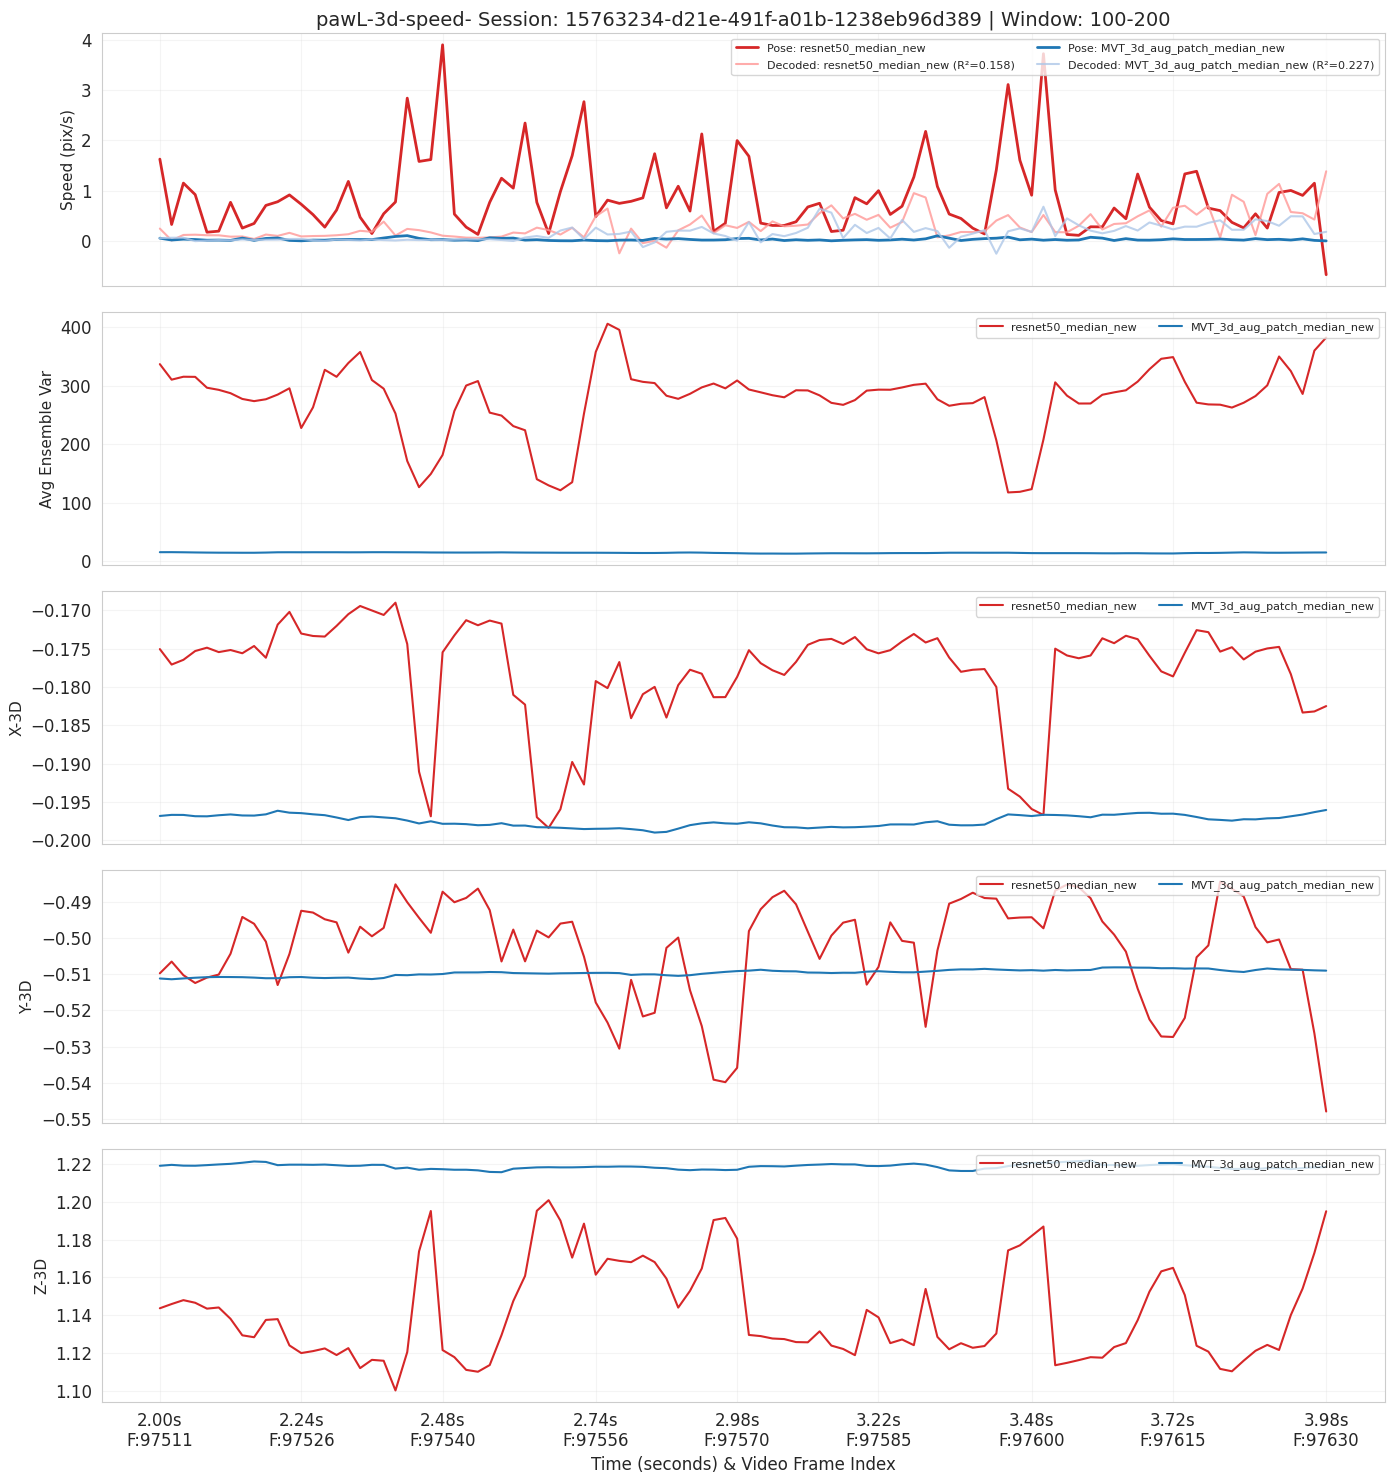

In [672]:
plots_to_show = ['speed','avg_var','x_3d', 'y_3d', 'z_3d']

plot_pose_results(results, pose_models, colors, eid, plots_to_show, start_time=100, end_time=200)

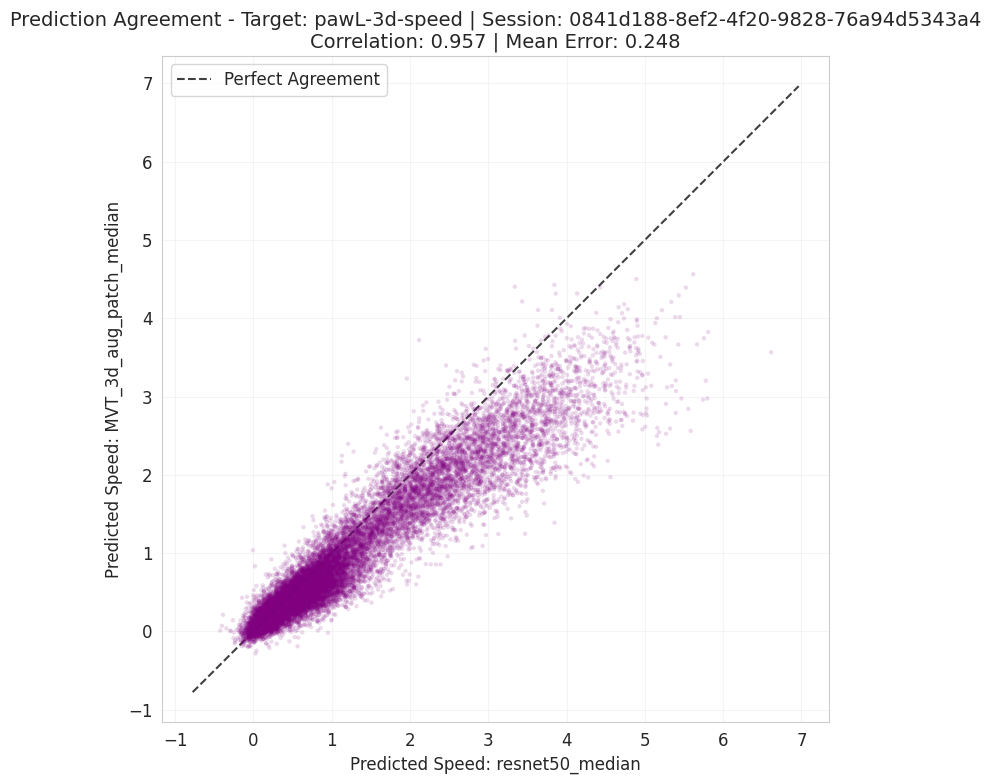

In [49]:
def plot_prediction_agreement(results, pose_models,target=target):
    """
    Creates a scatter plot comparing the neural predictions of two models.
    """
    if len(pose_models) < 2:
        print("Need at least two models to compare.")
        return

    # Get the flattened predictions for the first two models
    m1, m2 = pose_models[0], pose_models[1]
    pred1 = results[m1]['pred_flattened']
    pred2 = results[m2]['pred_flattened']
    
    # Ensure they are the same length (they should be for the same session)
    min_len = min(len(pred1), len(pred2))
    pred1, pred2 = pred1[:min_len], pred2[:min_len]

    # Calculate disagreement metrics
    correlation = np.corrcoef(pred1, pred2)[0, 1]
    mean_diff = np.mean(np.abs(pred1 - pred2))
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Scatter plot with high transparency to see density
    ax.scatter(pred1, pred2, alpha=0.15, s=10, color='purple', edgecolors='none')
    
    # Add identity line (y=x) - where they would perfectly agree
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='Perfect Agreement')
    
    # Formatting
    ax.set_xlabel(f"Predicted Speed: {m1}", fontsize=12)
    ax.set_ylabel(f"Predicted Speed: {m2}", fontsize=12)
    target_without = target.replace("lightning-pose-", "")
    ax.set_title(f"Prediction Agreement - Target: {target_without} | Session: {eid}\nCorrelation: {correlation:.3f} | Mean Error: {mean_diff:.3f}", fontsize=14)
    
    ax.grid(True, alpha=0.2)
    ax.set_aspect('equal')
    ax.legend()
    
    plt.tight_layout()
    plt.show()  # Explicitly show the plot to prevent duplicate display
    return fig

# Call the function
fig = plot_prediction_agreement(results, pose_models)

In [50]:
from sklearn.metrics import mean_squared_error, r2_score

def analyze_disagreement_performance(results, pose_models, percentile=90, target=target):
    """
    Identifies frames where predictions differ most and evaluates 
    decoding performance on those specific frames.
    """
    m1, m2 = pose_models[0], pose_models[1]
    
    # 1. Get predictions and ground truths
    p1, p2 = results[m1]['pred_flattened'], results[m2]['pred_flattened']
    y1, y2 = results[m1]['y_flattened'], results[m2]['y_flattened']
    
    # 2. Compute absolute disagreement between the two NEURAL predictions
    disagreement = np.abs(p1 - p2)
    
    # 3. Define "High Disagreement" frames (e.g., the top 10% most different)
    threshold = np.percentile(disagreement, percentile)
    mask = disagreement >= threshold
    
    num_frames = np.sum(mask)
    print(f"Analyzing {num_frames} frames of high disagreement (Top {100-percentile}%)...")
    target_without = target.replace("lightning-pose-", "")
    print(f"Target: {target_without} | Session: {eid}")
    print(f"Disagreement threshold: {threshold:.3f} pix/s")
    
    # 4. Compute metrics ONLY on these frames
    metrics = {}
    for m in [m1, m2]:
        pred_subset = results[m]['pred_flattened'][mask]
        truth_subset = results[m]['y_flattened'][mask]
        
        mse = mean_squared_error(truth_subset, pred_subset)
        r2 = r2_score(truth_subset, pred_subset)
        corr = np.corrcoef(truth_subset, pred_subset)[0, 1]
        
        metrics[m] = {'mse': mse, 'r2': r2, 'corr': corr}
    
    # 5. Print Comparison
    print(f"\n{'Model':<25} | {'MSE (Loss)':<12} | {'R²':<10} | {'Correlation'}")
    print("-" * 65)
    for m in [m1, m2]:
        met = metrics[m]
        print(f"{m:<25} | {met['mse']:<12.4f} | {met['r2']:<10.3f} | {met['corr']:.3f}")
        
    return mask, metrics

# Run the analysis
disagreement_mask, disagreement_metrics = analyze_disagreement_performance(results, pose_models)

Analyzing 2340 frames of high disagreement (Top 10%)...
Target: pawL-3d-speed | Session: 0841d188-8ef2-4f20-9828-76a94d5343a4
Disagreement threshold: 0.653 pix/s

Model                     | MSE (Loss)   | R²         | Correlation
-----------------------------------------------------------------
resnet50_median           | 19.2613      | 0.080      | 0.294
MVT_3d_aug_patch_median   | 8.8259       | 0.095      | 0.318


# This code evaluates each model against its own internal "difficulty" (ensemble variance), which means that the 10th percentile" for Model A might have included different frames than the "10th percentile" for Model B.

 the bin r^2 for model resnet50_median is -1.5152503802304063
 the bin r^2 for model resnet50_median is -0.6549582301361283
 the bin r^2 for model resnet50_median is -0.29134927772547203
 the bin r^2 for model resnet50_median is -0.10456460637366138
 the bin r^2 for model resnet50_median is 0.027997434444537617
 the bin r^2 for model resnet50_median is 0.06519817531024918
 the bin r^2 for model resnet50_median is 0.16148757603750408
 the bin r^2 for model resnet50_median is 0.12005988647790888
 the bin r^2 for model resnet50_median is 0.16891674214993846
 the bin r^2 for model resnet50_median is 0.03729249525917466
 the bin r^2 for model MVT_3d_aug_patch_median is -0.7671370650131175
 the bin r^2 for model MVT_3d_aug_patch_median is -0.2128452342183278
 the bin r^2 for model MVT_3d_aug_patch_median is -0.05372990864593441
 the bin r^2 for model MVT_3d_aug_patch_median is 0.16353573109254615
 the bin r^2 for model MVT_3d_aug_patch_median is 0.23153663669584812
 the bin r^2 for model MVT

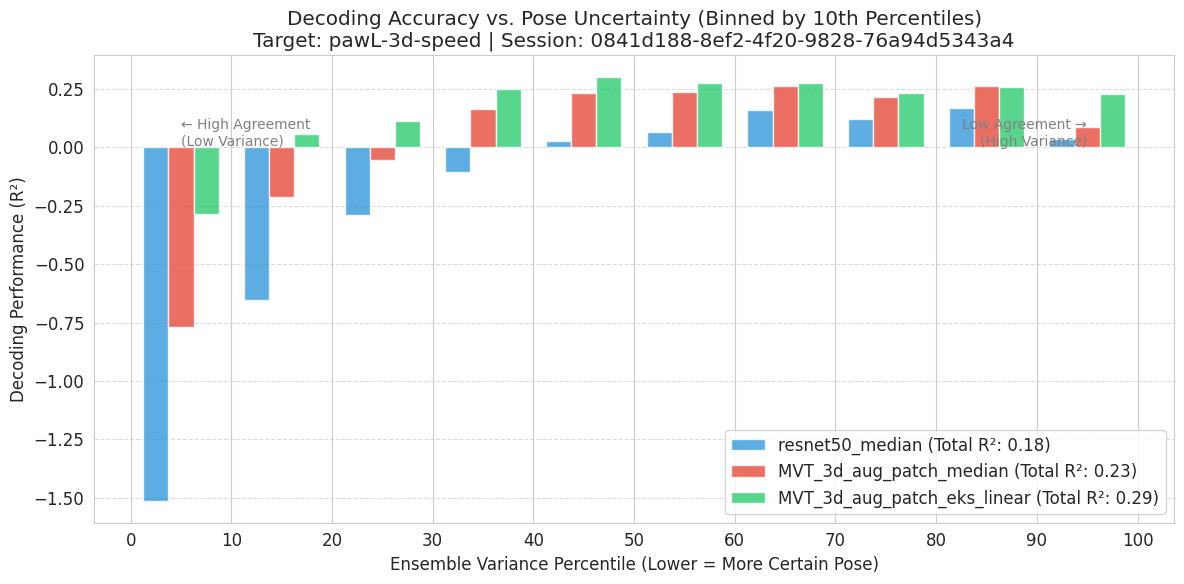

In [51]:

def plot_performance_by_variance_percentiles(results, pose_models, n_bins=10):
    """
    Bins the data by ensemble variance percentiles and computes R^2 for each bin.
    """
    plt.figure(figsize=(12, 6))
    
    # Define the percentile edges (0, 10, 20, ..., 100)
    percentiles = np.linspace(0, 100, n_bins + 1)
    bin_centers = (percentiles[:-1] + percentiles[1:]) / 2
    
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']
    
    for i, model_name in enumerate(pose_models):
        res = results[model_name]
        
        # Get flattened ground truth, predictions, and variance
        y_true = res['y_flattened']
        y_pred = res['pred_flattened']
        
        # Use the unified average variance we calculated during loading
        if 'avg_ens_var_flattened' not in res:
            print(f"Skipping {model_name}: No ensemble variance found.")
            continue
            
        var = res['avg_ens_var_flattened']
        
        # Calculate percentile thresholds for this model's variance
        thresholds = np.percentile(var, percentiles)
        
        bin_r2s = []
        bin_counts = []
        
        for j in range(n_bins):
            # Create mask for frames in this variance percentile bin
            lower = thresholds[j]
            upper = thresholds[j+1]
            
            # Handle the last bin inclusive edge
            if j == n_bins - 1:
                mask = (var >= lower) & (var <= upper)
            else:
                mask = (var >= lower) & (var < upper)
            
            if np.sum(mask) > 10:  # Need enough points for a stable R2
                r2 = r2_score(y_true[mask], y_pred[mask])
                bin_r2s.append(r2)
            else:
                bin_r2s.append(0)
            bin_counts.append(np.sum(mask))
            print(f" the bin r^2 for model {model_name} is {r2}")

            
        # Plotting the bars
        # Offsetting bars slightly so they don't overlap if comparing multiple models
        width = 10 / (len(pose_models) + 1)
        offset = (i - len(pose_models)/2 + 0.5) * width
        
        plt.bar(bin_centers + offset, bin_r2s, width=width, 
                label=f"{model_name} (Total R²: {res['r2']:.2f})", 
                color=colors[i % len(colors)], alpha=0.8)

    plt.xlabel('Ensemble Variance Percentile (Lower = More Certain Pose)')
    plt.ylabel('Decoding Performance (R²)')
    target_without = target.replace("lightning-pose-", "")
    plt.title(f'Decoding Accuracy vs. Pose Uncertainty (Binned by 10th Percentiles)\nTarget: {target_without} | Session: {eid}')
    plt.xticks(percentiles)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add info about what low/high percentiles mean
    plt.text(5, plt.ylim()[1]*0.02, "← High Agreement\n(Low Variance)", ha='left', fontsize=10, color='gray')
    plt.text(95, plt.ylim()[1]*0.02, "Low Agreement →\n(High Variance)", ha='right', fontsize=10, color='gray')

    plt.tight_layout()
    plt.show()

# Run the analysis
plot_performance_by_variance_percentiles(results, pose_models)

# To compare them fairly on the exact same frames, we should use a shared uncertainty scale. we do this by averging the ensemble variances of both pose models to define a single "global difficulty" for every frame. Same frames for all of the precentiles.

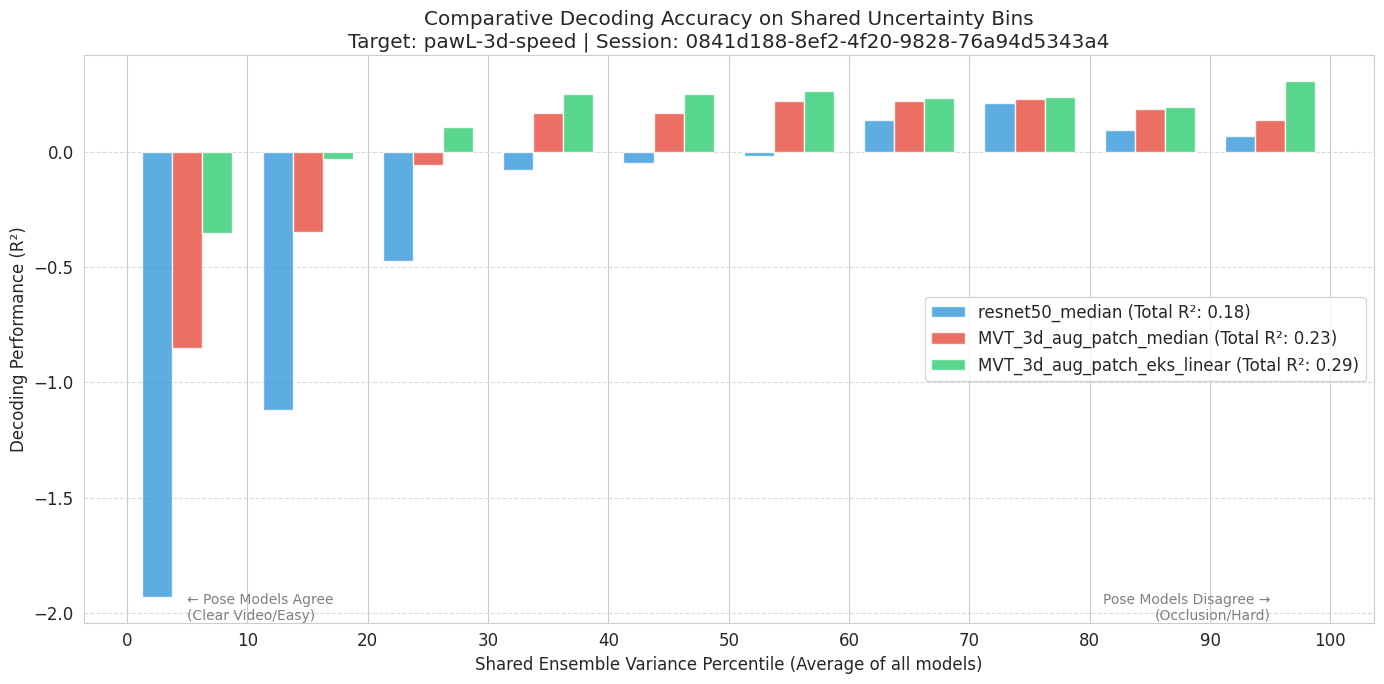

In [52]:
def plot_performance_by_shared_variance(results, pose_models, n_bins=10):
    """
    Computes a shared uncertainty scale by averaging variances from all models,
    then evaluates each model on the exact same frames per bin.
    """
    # 1. Ensure models are aligned and compute shared variance
    # (Assuming all models have the same number of frames from the same CV splits)
    all_vars = []
    for m in pose_models:
        if 'avg_ens_var_flattened' in results[m]:
            all_vars.append(results[m]['avg_ens_var_flattened'])
    
    if not all_vars:
        print("Error: No ensemble variance found in results.")
        return

    # Compute the average variance across all pose models for every frame
    shared_var = np.mean(all_vars, axis=0)
    # shared_var = np.max(all_vars, axis=0)
    
    # 2. Define shared percentile thresholds based on this global scale
    percentiles = np.linspace(0, 100, n_bins + 1)
    thresholds = np.percentile(shared_var, percentiles)
    bin_centers = (percentiles[:-1] + percentiles[1:]) / 2
    
    # 3. Plotting
    plt.figure(figsize=(14, 7))
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']
    width = 10 / (len(pose_models) + 1)
    
    for i, model_name in enumerate(pose_models):
        res = results[model_name]
        y_true = res['y_flattened']
        y_pred = res['pred_flattened']
        
        bin_r2s = []
        
        for j in range(n_bins):
            # Use the SHARED_VAR to create the mask (same frames for all models)
            lower, upper = thresholds[j], thresholds[j+1]
            if j == n_bins - 1:
                mask = (shared_var >= lower) & (shared_var <= upper)
            else:
                mask = (shared_var >= lower) & (shared_var < upper)
            
            if np.sum(mask) > 10:
                r2 = r2_score(y_true[mask], y_pred[mask])
                bin_r2s.append(r2)
            else:
                bin_r2s.append(0)
        
        offset = (i - len(pose_models)/2 + 0.5) * width
        plt.bar(bin_centers + offset, bin_r2s, width=width, 
                label=f"{model_name} (Total R²: {res['r2']:.2f})", 
                color=colors[i % len(colors)], alpha=0.8)

    plt.xlabel('Shared Ensemble Variance Percentile (Average of all models)')
    plt.ylabel('Decoding Performance (R²)')
    target_without = target.replace("lightning-pose-", "")
    plt.title(f'Comparative Decoding Accuracy on Shared Uncertainty Bins\nTarget: {target_without} | Session: {eid}')
    plt.xticks(percentiles)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.text(5, plt.ylim()[0], "← Pose Models Agree\n(Clear Video/Easy)", ha='left', va='bottom', fontsize=10, color='gray')
    plt.text(95, plt.ylim()[0], "Pose Models Disagree →\n(Occlusion/Hard)", ha='right', va='bottom', fontsize=10, color='gray')

    plt.tight_layout()
    plt.show()

# Run the updated analysis
plot_performance_by_shared_variance(results, pose_models)

In [89]:
import pandas as pd

# 1. Load Alignment and Timestamps
common_data_path = Path("/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/ibl_aligned") / eid
alignment_info = np.load(common_data_path / "alignment_info.npy", allow_pickle=True).item()
trial_intervals = alignment_info["trial_intervals"] 

timestamp_file = Path("/media/lenny-aharon/T7/ibl-mouse/timestamps") / f"_ibl_leftCamera.times.{eid}.npy"
frame_times = np.load(timestamp_file)

# 2. Get the trials in the order they appear in your plot
orig_trial_ids = results[pose_models[0]]['test_original_trial_ids']

mapping_list = []

for i, orig_id in enumerate(orig_trial_ids):
    # Get the start and end time for this 2-second trial
    t_start, t_end = trial_intervals[orig_id]
    
    # Find the exact indices in the 100,000 frame video
    raw_frame_start = np.searchsorted(frame_times, t_start, side="left")
    raw_frame_end = np.searchsorted(frame_times, t_end, side="right")
    
    mapping_list.append({
        'Plot_Trial_Index': i,
        'Plot_Time_Range': f"{i*2}-{(i+1)*2}s",
        'Session_Trial_ID': orig_id,
        'Video_Frame_Start': raw_frame_start,
        'Video_Frame_End': raw_frame_end,
        'Total_Video_Frames': raw_frame_end - raw_frame_start
    })

# Display as a table
mapping_df = pd.DataFrame(mapping_list)
print(mapping_df.head(10)) # Show first 10 trials

   Plot_Trial_Index Plot_Time_Range  Session_Trial_ID  Video_Frame_Start  \
0                 0            0-2s                 9               3398   
1                 1            2-4s                46              11969   
2                 2            4-6s                36               9966   
3                 3            6-8s               341              80932   
4                 4           8-10s               299              70857   
5                 5          10-12s               412              96972   
6                 6          12-14s                60              15437   
7                 7          14-16s               295              69962   
8                 8          16-18s               269              64183   
9                 9          18-20s               125              30399   

   Video_Frame_End  Total_Video_Frames  
0             3520                 122  
1            12091                 122  
2            10088                 122  

# This is Good until here